# Martingale Property Test — `data/results_mp`

This notebook tests whether the **martingale property** holds for the belief
trajectories collected under `data/results_mp/*/martingale_check/iterative/`.

## Background

Each run repeatedly feeds the model's own previously *sampled* answers back
into its own prompt (self-conditioning) and records the predictive
distribution $\theta_k = p(y \mid x, \hat y_{1:k})$ at every step
$k = 0, \dots, K$, where $\hat y_{1:k}$ are labels sampled from the model's
own earlier predictions (not new external evidence).

If the model is a well-calibrated Bayesian reasoner conditioning on data that
carries *no new information* (its own samples), the sequence
$(\theta_k)_{k \ge 0}$ should behave like a **martingale**:

$$\mathbb{E}[\theta_{k+1} \mid \mathcal{F}_k] = \theta_k \qquad\Longrightarrow\qquad \mathbb{E}[\theta_k] = \theta_0 \ \ \forall k$$

Concretely we check four necessary conditions, each with its own test:

| # | Property | Test |
|---|----------|------|
| 1 | **Mean stability** — the average belief doesn't drift from $\theta_0$ | TV / L1 distance of $\theta_k$ vs $\theta_0$, paired t-test per class, two-sample KS test |
| 2 | **No systematic step-to-step trend** — increments $\Delta\theta_k=\theta_{k+1}-\theta_k$ have zero mean and aren't predictable from $\theta_k$ | OLS regression of $\Delta\theta_k$ on $\theta_k$ (the "Martingale Score" $\hat\beta_1$) |
| 3 | **Uncorrelated increments** — a true martingale has $\mathrm{Cov}(\Delta\theta_i, \Delta\theta_j)=0$ for $i\ne j$ | Ljung–Box test for autocorrelation of $\Delta\theta_k$ |
| 4 | **(Optional) shrinking uncertainty** — under genuine Bayesian updating, epistemic uncertainty should *not* need to grow; entropy trend is reported for context | Spearman correlation of entropy vs. step |

A model that passes all four is self-consistent: repeatedly "showing itself"
its own answers doesn't systematically move its beliefs. Violations indicate
**belief entrenchment** (the model becomes overconfident in whatever it
happened to sample first) or **drift** (the model's belief wanders without
new evidence).


In [1]:
import glob
import os.path as osp
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import rel_entr
from scipy.stats import gaussian_kde, ks_2samp, chi2
from scipy.integrate import cumulative_trapezoid
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.dpi"] = 100
#np.set_printoptions(suppress=True, precision=4)


## 1. Discover available runs

Scan `data/results_mp/*/martingale_check/iterative/martingale_results.npz`.
Folder names encode `<dataset>_<model>` (e.g. `arc_c_deepseek_v4_pro` →
dataset `arc_c`, model `deepseek_v4_pro`). Runs that never finished (only a
`.log` file, no `.npz`) are reported but skipped.


In [2]:
RUN_TYPE = 'iterative'
RESULTS_ROOT = osp.abspath(osp.join("..", "data", "results_mp"))
MODEL_NAME = "gpt4o_mini" # All or specific model name


print("Results root:", RESULTS_ROOT)

_KNOWN_DATASETS = sorted(
    ["arc_c", "arc_e", "csqa", "obqa", "race", "sciq"], key=len, reverse=True
)

def parse_run_folder(folder_name: str):
    """Split '<dataset>_<model>' into (dataset, model) using known dataset codes."""
    for ds in _KNOWN_DATASETS:
        prefix = ds + "_"
        if folder_name.startswith(prefix):
            return ds, folder_name[len(prefix):]
    return folder_name, "unknown"

all_run_dirs = sorted(glob.glob(osp.join(RESULTS_ROOT, "*")))

registry_rows = []
for run_dir in all_run_dirs:
    folder = osp.basename(run_dir)
    dataset, model = parse_run_folder(folder)
    npz_path = osp.join(run_dir, "martingale_check", RUN_TYPE, "martingale_results.npz")
    registry_rows.append({
        "folder": folder,
        "dataset": dataset,
        "model": model,
        "npz_path": npz_path,
        "available": osp.exists(npz_path),
    })

registry = pd.DataFrame(registry_rows)

if MODEL_NAME != "all":
    registry = registry[registry["model"] == MODEL_NAME]

registry


Results root: /Users/alicansahin/Desktop/LMU/SoSe 26/thesis/uq_with_martingale_posteriors/data/results_mp


,folder,dataset,model,npz_path,available
8,obqa_gpt4o_mini,obqa,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True


In [3]:
missing = registry.loc[~registry["available"], "folder"].tolist()
if missing:
    print(f"Skipping {len(missing)} incomplete run(s) (no martingale_results.npz found): {missing}")

registry = registry[registry["available"]].reset_index(drop=True)
print(f"\n{len(registry)} completed run(s) available for testing.")



1 completed run(s) available for testing.


## 2. Loading & normalization helpers

Each `.npz` stores one dict per random seed (top-level key = seed string).
`distributions` is `(N, K+1, C)`: `N` questions, `K+1` steps (`k=0` is the
direct-query prior, `k=1..K` are self-conditioned posteriors), `C` answer
choices. `normalize_distributions` also accepts the `(N, J, K+1, C)` shape
used by PPR-mode runs (`J` independent trajectories per question), so this
notebook keeps working if PPR results are added to `results_mp` later.


In [4]:
SEED = '60'

In [5]:
def normalize_distributions(d: np.ndarray) -> np.ndarray:
    """Coerce to (Q, J, K+1, C). (K+1,C)->(1,1,K+1,C); (Q,K+1,C)->(Q,1,K+1,C)."""
    if d.ndim == 2:
        d = d[np.newaxis, np.newaxis, :]
    elif d.ndim == 3:
        d = d[:, np.newaxis, :]
    return d


def load_run(npz_path: str, seed: str = None) -> dict:
    """Load one seed's results dict from a martingale_results.npz file."""
    raw = np.load(npz_path, allow_pickle=True)
    seed = seed or list(raw.keys())[0]
    dat = raw[seed].item()
    dat["distributions"] = normalize_distributions(np.asarray(dat["distributions"], dtype=np.float64))
    return dat


# Sanity-check the loader on the first available run
_example = load_run(registry.loc[0, "npz_path"], seed=SEED)
Q, J, Kp1, C = _example["distributions"].shape
print(f"Example run: {registry.loc[0, 'folder']}")
print(f"  distributions shape: (Q={Q} questions, J={J} trajectories, K+1={Kp1} steps, C={C} classes)")
print(f"  keys: {list(_example.keys())}")


Example run: obqa_gpt4o_mini
  distributions shape: (Q=5 questions, J=20 trajectories, K+1=101 steps, C=4 classes)
  keys: ['distributions', 'true_labels', 'data_indices', 'input_texts', 'prompt_history', 'K', 'mean_tv', 'pass_rate_tv_005', 'pass_rate_tv_010', 'mean_l1', 'accuracy_at_p0', 'tv_per_question', 'mean_l1_per_question', 'drift_profile', 'class_variance']


## 3. Headline metrics for every run

These summary statistics were already computed by `martingale_property.py`
and stored in the `.npz` (see `compute_martingale_metrics`); we simply
collect them here for a side-by-side comparison across datasets/models.

- **mean_tv** — mean total-variation distance between $\bar\theta =
  \mathrm{mean}_k(\theta_k, k\ge1)$ and $\theta_0$, averaged over questions
  (0 = perfect martingale, 1 = maximal drift).
- **pass_rate_tv_0.05 / 0.10** — fraction of questions with TV drift below
  0.05 / 0.10.
- **mean_l1** — mean $\lVert\theta_k-\theta_0\rVert_1$ over all steps and
  questions.
- **accuracy_at_p0** — greedy accuracy using only the direct-query prior
  $\theta_0$ (sanity check that the underlying model is doing the task at
  all).


In [6]:
overview_rows = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    Q, J, Kp1, C = dat["distributions"].shape
    overview_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "N_questions": Q,
        "J_trajectories": J,
        "K_steps": Kp1 - 1,
        "C_classes": C,
        "accuracy_at_p0": float(dat["accuracy_at_p0"]),
        "mean_tv": float(dat["mean_tv"]),
        "pass_rate_tv_0.05": float(dat["pass_rate_tv_005"]),
        "pass_rate_tv_0.10": float(dat["pass_rate_tv_010"]),
        "mean_l1": float(dat["mean_l1"]),
    })

overview = pd.DataFrame(overview_rows).sort_values("mean_tv").reset_index(drop=True)
overview.style.format({
    "accuracy_at_p0": "{:.3f}", "mean_tv": "{:.4f}", "pass_rate_tv_0.05": "{:.3f}",
    "pass_rate_tv_0.10": "{:.3f}", "mean_l1": "{:.4f}",
}).background_gradient(subset=["mean_tv"], cmap="Reds")


,dataset,model,N_questions,J_trajectories,K_steps,C_classes,accuracy_at_p0,mean_tv,pass_rate_tv_0.05,pass_rate_tv_0.10,mean_l1
0,obqa,gpt4o_mini,10,1,100,4,1.000,0.0341,0.800,0.800,0.0682


## 3b. Argmax agreement (label-level drift)

`mean_tv`/`mean_l1` and the parametric tests in Section 4 are underpowered
here for two compounding reasons: (a) each run has only **N=10 questions**,
so paired/KS tests have little chance of reaching significance even for a
real shift; (b) several runs (the `deepseek_v4_pro` ones) return
near one-hot distributions (no `logprobs`, effectively a single greedy
sample per call), which collapses most soft-probability tests onto a
handful of point masses.

For this regime the most direct, assumption-free question is simply: **does
self-conditioning ever change which answer the model would pick?** For each
question we compare $\arg\max_c \theta_k[c]$ at every step $k\ge1$ against
$\arg\max_c \theta_0[c]$ and report the disagreement rate. This needs no
p-value to be informative — it's the raw behavioral fact the martingale
property is meant to rule out.


In [8]:
argmax_rows = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    p_all = dat["distributions"].mean(axis=1)   # (Q, K+1, C)
    argmax_all = p_all.argmax(axis=-1)          # (Q, K+1)
    label0 = argmax_all[:, :1]                  # (Q, 1)
    disagree = (argmax_all[:, 1:] != label0)    # (Q, K)  True where step k picks a different class than step 0

    argmax_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "flip_rate": float(disagree.mean()),                       # fraction of (question, step) pairs that disagree
        "questions_with_any_flip": int((disagree.any(axis=1)).sum()),
        "n_questions": disagree.shape[0],
    })

argmax_summary = pd.DataFrame(argmax_rows).sort_values("flip_rate", ascending=False).reset_index(drop=True)
argmax_summary["pct_questions_with_flip"] = argmax_summary["questions_with_any_flip"] / argmax_summary["n_questions"]
argmax_summary.style.format({"flip_rate": "{:.4f}", "pct_questions_with_flip": "{:.1%}"})


,dataset,model,flip_rate,questions_with_any_flip,n_questions,pct_questions_with_flip
0,obqa,gpt4o_mini,0.0100,2,10,20.0%


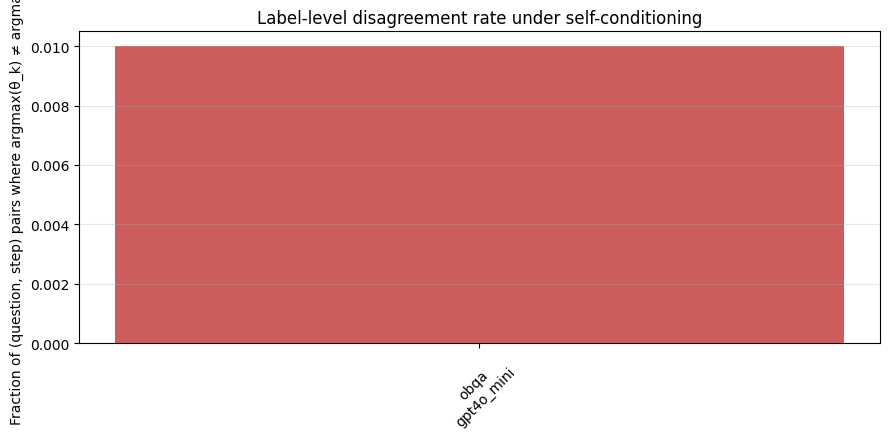

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = argmax_summary["dataset"] + "\n" + argmax_summary["model"]
ax.bar(labels, argmax_summary["flip_rate"], color="indianred")
ax.set_ylabel("Fraction of (question, step) pairs where argmax(θ_k) ≠ argmax(θ_0)")
ax.set_title("Label-level disagreement rate under self-conditioning")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 4. Statistical test suite

The overview above only tells us *how much* belief moved on average. The
functions below test *whether that movement is statistically meaningful*
(and in which direction), following the four properties in the intro.

All functions operate on `p_all`, the trajectories averaged over
trajectories $J$ (identity when $J=1$, i.e. for every run currently in
`results_mp`): shape `(Q, K+1, C)`.


In [10]:
EPS = 1e-9

def to_clr(p: np.ndarray) -> np.ndarray:
    """Centered log-ratio transform: maps the simplex to unconstrained R^C."""
    p = np.clip(p, EPS, 1)
    log_p = np.log(p)
    return log_p - log_p.mean(axis=-1, keepdims=True)


def smooth_cdf(values: np.ndarray, x_grid: np.ndarray, bw: float = 0.5) -> np.ndarray:
    """KDE-smoothed CDF; falls back to the ECDF if the sample is (near-)degenerate."""
    values = np.asarray(values)
    if values.std() < 0.1 or len(values) < 3:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)
    try:
        kde = gaussian_kde(values, bw_method=bw)
        density = kde(x_grid)
        cdf = cumulative_trapezoid(density, x_grid, initial=0)
        cdf /= cdf[-1]
        return cdf
    except np.linalg.LinAlgError:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)


### Test 1 — Mean stability (TV/L1 drift + paired tests + CLR-space CDF comparison)

Compares $\theta_0$ (Scenario 1: direct prediction) against
$\{\theta_k\}_{k=1}^K$ (Scenario 2: self-conditioned). Under the martingale
property these should be statistically indistinguishable:
$\mathbb{E}_k[\theta_k] = \theta_0$.


In [ ]:
## Here we give the average probabilitiees over J independent pass because t-test assumes that the samples are independent. 
## If we do not average over J, then the t-test will be invalid because the samples are not independent.
def scenario_comparison_test(p_0: np.ndarray, p_others: np.ndarray, alpha: float = 0.05,
                              class_labels=None, make_plots: bool = True, title: str = ""):
    """
    p_0      : (Q, C)    direct-query prior, one per question
    p_others : (Q, K, C) self-conditioned posteriors, K steps per question

    Returns a dict of scalar statistics plus a boolean 'martingale_consistent' verdict.
    """
    Q, K, C = p_others.shape
    class_labels = class_labels or [chr(65 + c) for c in range(C)]
    steps = np.arange(1, K + 1)

    p_others_mean = p_others.mean(axis=1)  # (Q, C) — per-question average posterior

    tv_per_q = 0.5 * np.abs(p_0 - p_others_mean).sum(axis=1)                 # (Q,)
    tv_per_step = 0.5 * np.abs(p_0[:, None, :] - p_others).sum(axis=-1).mean(axis=0)  # (K,)

    m_dist = 0.5 * (p_0 + p_others_mean)
    jsd = 0.5 * (
        rel_entr(p_0, np.clip(m_dist, EPS, 1)).sum(axis=1)
        + rel_entr(p_others_mean, np.clip(m_dist, EPS, 1)).sum(axis=1)
    )  # (Q,)

    # Paired t-test also runs in CLR space, for the same reason as the KS
    # test below: on the raw simplex, two supposedly-identical probabilities
    # (e.g. both ~0.1) can differ by ~1e-11 due to float32->float64 noise,
    # and ttest_rel divides by the standard error *of that noise*, which can
    # spuriously cross p<0.05. CLR's EPS-clipping removes it.
    p_0_clr_t = to_clr(p_0)
    p_others_mean_clr = to_clr(p_others_mean)
    ttest_pvals = np.array([
        stats.ttest_rel(p_0_clr_t[:, c], p_others_mean_clr[:, c]).pvalue for c in range(C)
    ])

    # Wilcoxon signed-rank test as a non-parametric robustness check: the
    # paired t-test above assumes the per-question CLR differences are
    # normal, which is shaky here (class columns mix "correct answer" and
    # "distractor" cases, and CLR is heavy-tailed near the EPS clip). If
    # the two disagree, treat the t-test verdict with more suspicion.
    def _wilcoxon_pval(x, y):
        try:
            return stats.wilcoxon(x, y, zero_method="wilcox").pvalue
        except ValueError:
            # all paired differences are exactly zero -> no evidence of a shift
            return 1.0

    wilcoxon_pvals = np.array([
        _wilcoxon_pval(p_0_clr_t[:, c], p_others_mean_clr[:, c]) for c in range(C)
    ])

    # KS test is run in CLR space (not on raw probabilities): near one-hot
    # providers (e.g. a chat API with no logprobs) emit "near-zero" entries
    # that differ only by float32 noise far below any meaningful precision
    # (e.g. 1.00000001e-10 vs 9.99999944e-11). Pooling millions of such raw
    # values makes ks_2samp detect that noise as a "significant" shift even
    # when every distribution is bit-for-bit the same one-hot vector. CLR's
    # EPS-clipping collapses all such near-zero entries to one value, so the
    # test again reflects genuine distributional shape differences only.

    ## Look at closely and try to understand
    p_0_clr = to_clr(p_0)
    p_others_clr = to_clr(p_others)
    ks_stat, ks_pval = ks_2samp(p_others_clr.reshape(-1, C).ravel(), np.tile(p_0_clr, (K, 1)).ravel())

    n_sig_classes = int((ttest_pvals < alpha).sum())
    #martingale_consistent = bool(ks_pval >= alpha and n_sig_classes == 0)
    martingale_consistent = bool(n_sig_classes == 0)

    if make_plots:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
        fig.suptitle(f"Scenario comparison (θ_0 vs self-conditioned θ_k) — {title}", y=1.04)

        ax = axes[0]
        ax.bar(range(Q), tv_per_q, color="steelblue")
        ax.axhline(tv_per_q.mean(), color="red", linestyle="--", label=f"mean={tv_per_q.mean():.3f}")
        ax.set_xlabel("Question"); ax.set_ylabel("TV distance")
        ax.set_title("TV(θ_0, mean_k θ_k) per question"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.plot(steps, tv_per_step, marker="o", color="steelblue")
        ax.axhline(tv_per_step.mean(), color="red", linestyle="--", label=f"mean={tv_per_step.mean():.3f}")
        ax.set_xlabel("Step k"); ax.set_ylabel("Mean TV distance vs θ_0")
        ax.set_title("TV drift over self-conditioning steps"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[2]
        ax.bar(range(Q), jsd, color="orange")
        ax.axhline(jsd.mean(), color="red", linestyle="--", label=f"mean={jsd.mean():.3f}")
        ax.set_xlabel("Question"); ax.set_ylabel("JSD")
        ax.set_title("Jensen-Shannon divergence per question"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[3]
        x = np.arange(C); w = 0.35
        ax.bar(x - w/2, p_0.mean(axis=0), width=w, label="θ_0 (prior)", color="steelblue")
        ax.bar(x + w/2, p_others_mean.mean(axis=0), width=w, label="mean θ_k (posterior)", color="orange")
        for c in range(C):
            if ttest_pvals[c] < alpha:
                ymax = max(p_0[:, c].mean(), p_others_mean[:, c].mean()) + 0.01
                ax.text(c, ymax, "*", ha="center", fontsize=14, color="red")
        ax.set_xticks(x); ax.set_xticklabels(class_labels)
        ax.set_ylabel("Mean probability"); ax.set_title("Mean belief per class (* = p<α)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    n_sig_classes_wilcoxon = int((wilcoxon_pvals < alpha).sum())

    return {
        "tv_mean": float(tv_per_q.mean()),
        "jsd_mean": float(jsd.mean()),
        "ks_stat": float(ks_stat), "ks_pval": float(ks_pval),
        "n_sig_classes": n_sig_classes, "n_classes": C,
        "wilcoxon_pvals": wilcoxon_pvals, "n_sig_classes_wilcoxon": n_sig_classes_wilcoxon,
        "martingale_consistent": martingale_consistent,
    }


### Test 2 — Marginal-distribution KS test per step + epistemic entropy trend

For each step $k$, we CLR-transform $\theta_k$ pooled over all questions and
run a two-sample Kolmogorov–Smirnov test against the pooled $\theta_0$
values. If the martingale property holds, no step should show a
significant shift. We also report the trend of mean predictive entropy
across steps for context (a genuinely Bayesian process is *not* required to
have monotonically shrinking entropy here, since no new evidence is being
introduced — a flat trend is consistent with the martingale property; a
strong monotonic *decrease* signals overconfidence/entrenchment, and an
*increase* signals eroding certainty).


In [12]:
def marginal_ks_and_entropy_test(p_all: np.ndarray, alpha: float = 0.05,
                                  make_plots: bool = True, title: str = ""):
    """p_all: (Q, T, C) trajectories (T = K+1 steps, step 0 = prior)."""
    Q, T, C = p_all.shape
    steps = np.arange(T)
    p_clr = to_clr(p_all)

    ref = p_clr[:, 0, :].ravel()
    ks_pvals = np.ones(T)
    ks_stats = np.zeros(T)
    for m in range(1, T):
        ks_stats[m], ks_pvals[m] = ks_2samp(ref, p_clr[:, m, :].ravel())

    p_clip = np.clip(p_all, EPS, 1)
    entropy = -(p_all * np.log(p_clip)).sum(axis=-1)  # (Q, T)
    mean_entropy = entropy.mean(axis=0)
    rho, rho_pval = stats.spearmanr(steps[1:], mean_entropy[1:])

    n_sig = int((ks_pvals[1:] < alpha).sum())
    martingale_consistent = bool(n_sig == 0)

    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        fig.suptitle(f"Marginal KS test & entropy trend — {title}", y=1.03)

        ax = axes[0]
        ax.plot(steps[1:], ks_pvals[1:], marker="o", color="steelblue", markersize=3)
        ax.axhline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        ax.set_xlabel("Step k"); ax.set_ylabel("KS p-value (θ_k vs θ_0)")
        ax.set_title(f"{n_sig}/{T-1} steps significantly shifted")
        ax.legend(); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.plot(steps, mean_entropy, marker="o", color="orange", markersize=3)
        ax.set_xlabel("Step k"); ax.set_ylabel("Mean entropy H(θ_k)")
        ax.set_title(f"Entropy trend — Spearman ρ={rho:.3f}, p={rho_pval:.4f}")
        ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    return {
        "n_sig_steps": n_sig, "n_steps": T - 1,
        "entropy_rho": float(rho), "entropy_rho_pval": float(rho_pval),
        "martingale_consistent": martingale_consistent,
    }


### Test 3 — Martingale Score: does $\Delta\theta_k$ depend on $\theta_k$?

For every question we have one path $\theta_0, \theta_1, \dots, \theta_K$
(here each question *is* an independent path — there is no additional
trajectory dimension in the iterative-mode data). Pooling
$(\theta_k, \Delta\theta_k)$ pairs across all questions and steps, we
regress the increment on the *scalar* top-class belief
$b_k = \max_c \theta_k[c]$:

$$\Delta b_k = \beta_0 + \beta_1 \, b_k + \varepsilon_k$$

- $\hat\beta_1 \approx 0$ (not significant) → martingale holds
- $\hat\beta_1 > 0$ → **belief entrenchment** (confident beliefs get more confident)
- $\hat\beta_1 < 0$ → mean-reversion


In [13]:
def martingale_score(distributions: np.ndarray, alpha: float = 0.05,
                      make_plots: bool = True, title: str = ""):
    """distributions: (Q, J, K+1, C). Pools all Q*J independent paths.

    Some providers (e.g. a chat API with no logprobs access, single-sample
    greedy decoding) return near one-hot distributions, so the top-class
    belief b_k = max_c θ_k[c] is ~1 at every step for every path. The
    regression predictor is then degenerate (zero variance) and OLS is
    undefined; this is reported explicitly rather than crashing or silently
    returning a bogus '0 == pass'.
    """
    Q, J, Kp1, C = distributions.shape
    b = distributions.max(axis=-1).reshape(Q * J, Kp1)  # (paths, K+1)

    X = b[:, :-1].reshape(-1)
    diff = (b[:, 1:] - b[:, :-1]).reshape(-1)
    n = len(X)

    if X.std() < 1e-8:
        if make_plots:
            print(f"[martingale_score] SKIPPED for {title}: max-belief is constant "
                  f"(std={X.std():.2e}) — model returns near one-hot distributions, "
                  "so this regression test is not applicable.")
        return {
            "beta_1": float("nan"), "std_err": float("nan"), "p_value": float("nan"),
            "r2": float("nan"), "f_stat": float("nan"), "f_pvalue": float("nan"),
            "martingale_consistent": None,  # not applicable, neither pass nor fail
            "degenerate": True,
        }

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, diff)
    r2 = r_value ** 2
    t_stat = slope / std_err if std_err > 0 else 0.0
    f_stat = t_stat ** 2
    f_pvalue = stats.f.sf(f_stat, dfn=1, dfd=n - 2)

    martingale_consistent = bool(p_value >= alpha)

    if make_plots:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.scatter(X, diff, alpha=0.15, s=10, color="steelblue")
        xs = np.linspace(X.min(), X.max(), 50)
        ax.plot(xs, intercept + slope * xs, color="red", linewidth=2,
                label=f"β̂₁={slope:.3f} (p={p_value:.4f})")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_xlabel("b_k = max belief at step k")
        ax.set_ylabel("Δb = b_{k+1} - b_k")
        ax.set_title(f"Martingale Score — {title}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    return {
        "beta_1": float(slope), "std_err": float(std_err), "p_value": float(p_value),
        "r2": float(r2), "f_stat": float(f_stat), "f_pvalue": float(f_pvalue),
        "martingale_consistent": martingale_consistent,
        "degenerate": False,
    }


### Test 3b — Per-class Martingale Score

The pooled Martingale Score above collapses each step's belief to
$b_k = \max_c \theta_k[c]$ -- the confidence of whichever class currently
wins -- before regressing. That's a reasonable summary, but it isn't
literally the martingale condition from Definition 2.1, which is stated for
the *whole* belief vector $\theta_k$, not its argmax: entrenchment or
mean-reversion happening in a class that isn't the current top pick would be
invisible to the pooled test.

This runs the same regression **separately per class**, mirroring how
Test 1's paired t-test already loops `for c in range(C)`:

$$\Delta\theta_k[c] = \beta_0 + \beta_1 \, \theta_k[c] + \varepsilon_k \qquad \text{for each class } c$$

A class is marked **degenerate** (test not applicable, same convention as
the pooled version) if its own probability is essentially constant across
every path and step -- common for classes the model rarely favors, where
there's no variance to regress on. Martingale consistency requires every
*applicable* class's slope to be statistically insignificant, the same
all-or-nothing logic Test 1 uses for `n_sig_classes == 0`.


In [14]:
def martingale_score_per_class(distributions: np.ndarray, alpha: float = 0.05,
                                class_labels=None, make_plots: bool = True,
                                title: str = "") -> dict:
    """distributions: (Q, J, K+1, C). Per-class extension of martingale_score:
    instead of pooling to b_k = max_c theta_k[c] and running one regression,
    runs Delta theta_k[c] = beta_0 + beta_1 * theta_k[c] + eps separately for
    EACH class c, pooling over all Q*J paths and steps.

    Returns a dict with a 'per_class' list (one entry per class: beta_1,
    std_err, p_value, r2, degenerate, significant), plus n_sig_classes,
    n_applicable, n_degenerate, and an overall martingale_consistent verdict
    (None if every class is degenerate, else True iff n_sig_classes == 0).
    """
    Q, J, Kp1, C = distributions.shape
    class_labels = class_labels or [chr(65 + c) for c in range(C)]
    paths = distributions.reshape(Q * J, Kp1, C)  # (paths, K+1, C)

    per_class = []
    for c in range(C):
        theta_c = paths[:, :, c]  # (paths, K+1)
        X = theta_c[:, :-1].reshape(-1)
        diff = (theta_c[:, 1:] - theta_c[:, :-1]).reshape(-1)

        if X.std() < 1e-8:
            per_class.append({
                "class": class_labels[c], "beta_1": float("nan"), "std_err": float("nan"),
                "p_value": float("nan"), "r2": float("nan"),
                "degenerate": True, "significant": False,
            })
            continue

        slope, intercept, r_value, p_value, std_err = stats.linregress(X, diff)
        per_class.append({
            "class": class_labels[c], "beta_1": float(slope), "std_err": float(std_err),
            "p_value": float(p_value), "r2": float(r_value ** 2),
            "degenerate": False, "significant": bool(p_value < alpha),
            "_X": X, "_diff": diff, "_intercept": float(intercept),  # plotting only
        })

    applicable = [r for r in per_class if not r["degenerate"]]
    n_sig_classes = sum(1 for r in applicable if r["significant"])
    martingale_consistent = bool(n_sig_classes == 0) if applicable else None

    if make_plots:
        if not applicable:
            print(f"[martingale_score_per_class] SKIPPED plot for {title}: every class is "
                  f"degenerate (constant probability across all paths/steps).")
        else:
            ncols = len(applicable)
            fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5), squeeze=False)
            axes = axes[0]
            for i_ax, r in enumerate(applicable):
                ax = axes[i_ax]
                ax.scatter(r["_X"], r["_diff"], alpha=0.15, s=10, color="steelblue")
                xs = np.linspace(r["_X"].min(), r["_X"].max(), 50)
                color = "red" if r["significant"] else "green"
                ax.plot(xs, r["_intercept"] + r["beta_1"] * xs, color=color, linewidth=2,
                        label=f"β̂₁={r['beta_1']:.3f} (p={r['p_value']:.4f})")
                ax.axhline(0, color="gray", linewidth=0.8)
                ax.set_xlabel(f"θ_k[{r['class']}]")
                ax.set_ylabel(f"Δθ[{r['class']}]")
                ax.set_title(f"Class {r['class']}" + (" *" if r["significant"] else ""))
                ax.legend(fontsize=8); ax.grid(alpha=0.3)
            fig.suptitle(
                f"Per-class Martingale Score — {title}\n"
                f"({n_sig_classes}/{len(applicable)} applicable classes significant; "
                f"{C - len(applicable)} degenerate)", y=1.04
            )
            plt.tight_layout(); plt.show()

        skipped = [r["class"] for r in per_class if r["degenerate"]]
        if skipped:
            print(f"[martingale_score_per_class] Degenerate (skipped) classes for {title}: {skipped}")

    clean_per_class = [{k: v for k, v in r.items() if not k.startswith("_")} for r in per_class]

    return {
        "per_class": clean_per_class,
        "n_sig_classes": n_sig_classes,
        "n_applicable": len(applicable),
        "n_degenerate": C - len(applicable),
        "martingale_consistent": martingale_consistent,
    }


### Test 3c — Local-level (Kalman filter) drift + independence test

Both Martingale Score variants above regress $\Delta\theta_k$ on $\theta_k$,
which is mechanically biased toward $\hat\beta_1 \approx -1$ whenever the
series is mostly measurement noise around a stable value -- exactly the
regime this notebook's near-one-hot providers live in (see the discussion
above; verified both analytically and by simulation that pure noise alone
produces this same "significant" slope). That test cannot distinguish real
drift from noise at this scale.

**Test 4 (Ljung-Box on raw $\Delta\theta_k$) has the exact same problem.**
Differencing a noise-dominated series manufactures a spurious lag-1
autocorrelation of $\approx -0.5$ regardless of whether the underlying
process has any real dependence -- verified by simulation: pure i.i.d.
noise (a textbook-perfect martingale with zero real dependence) makes
Test 4 reject with $p \approx 0.00003$. So a "FAIL" from Test 4 in this
noise regime is not trustworthy evidence against the martingale property.

This test fixes both problems at once by fitting a **local-level
state-space model** (a Kalman filter) that explicitly separates real
signal from measurement noise:

$$\theta_k = \ell_k + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma^2_{\text{irregular}})$$
$$\ell_k = \ell_{k-1} + \eta_k, \qquad \eta_k \sim \mathcal{N}(0, \sigma^2_{\text{level}})$$

$\sigma^2_{\text{level}}$ is the variance of *real* step-to-step change in
the underlying belief $\ell_k$; $\sigma^2_{\text{irregular}}$ is
measurement/estimation noise on top of it.

- **Drift**: $H_0: \sigma^2_{\text{level}} = 0$ (no real drift) is tested via
  a likelihood-ratio test against the unrestricted model. Since $0$ sits on
  the *boundary* of the parameter space (variances can't be negative), the
  correct reference distribution is a 50:50 mixture of a point mass at 0
  and $\chi^2_1$ (Self & Liang, 1987), not a plain $\chi^2_1$.
- **Independence** (replaces Test 4's role): instead of Ljung-Box on raw
  differences, this runs Ljung-Box on the model's **innovations**
  (one-step-ahead prediction errors) -- the standard state-space diagnostic.
  Innovations don't inherit the differencing artifact because they're not a
  naive difference of raw noisy data; they're what's left over *after* the
  model's optimal prediction, which is genuinely expected to be white noise
  under a correctly-specified martingale-consistent process. Verified on
  the same pure-noise example: Test 4's raw-difference version rejects at
  $p \approx 0.00003$, while the innovations version correctly does not
  reject ($p \approx 0.35$–$0.74$ across lags).


In [15]:
def local_level_drift_test(theta_c: np.ndarray, alpha: float = 0.05, lags: int = 5) -> dict:
    """theta_c: (T,) one class's raw probability trajectory across T steps.

    Fits a local-level (random walk + noise) state-space model via the
    Kalman filter and returns two diagnostics from it, both immune to the
    differencing artifact that affects Test 3 (Martingale Score) and
    Test 4 (Ljung-Box on raw differences) -- see the markdown above:

    1. Drift: tests H0: sigma2_level = 0 (no real drift, just measurement
       noise) via a boundary-corrected likelihood-ratio test.
    2. Independence: runs Ljung-Box on the model's innovations (one-step-
       ahead prediction errors) instead of raw Delta-theta -- the standard,
       artifact-free way to check whether a state-space model's residuals
       are white noise. This is the corrected version of what Test 4 was
       trying to test.

    theta_c is rescaled to unit variance before fitting -- pure numerical
    stability for the MLE optimizer, since these probabilities can be as
    small as 1e-10, far outside the scale MLE solvers are tuned for. Both
    diagnostics are invariant to this linear rescaling; the returned
    variances and smoothed level are rescaled back to the original
    probability units.
    """
    y_raw = np.asarray(theta_c, dtype=np.float64)
    scale = 1.0 / (y_raw.std() + 1e-300)
    y = y_raw * scale

    mod_full = UnobservedComponents(y, level="local level")
    res_full = mod_full.fit(disp=False, maxiter=200)

    mod_restricted = UnobservedComponents(y, level="local level")
    with mod_restricted.fix_params({"sigma2.level": 1e-12}):
        res_restricted = mod_restricted.fit(disp=False, maxiter=200)

    lr_stat = max(0.0, 2 * (res_full.llf - res_restricted.llf))
    p_value = 0.5 * (1 - chi2.cdf(lr_stat, df=1))

    sigma2_level = float(res_full.params[mod_full.param_names.index("sigma2.level")]) / scale ** 2
    sigma2_irregular = float(res_full.params[mod_full.param_names.index("sigma2.irregular")]) / scale ** 2
    smoothed_level = res_full.smoothed_state[0] / scale  # back to original probability units

    # Independence check on innovations (replaces Test 4's raw-difference version)
    lb = res_full.test_serial_correlation(method="ljungbox", lags=lags)
    innovations_lb_stat = float(lb[0, 0, -1])
    innovations_lb_pvalue = float(lb[0, 1, -1])

    return {
        "sigma2_level": sigma2_level,
        "sigma2_irregular": sigma2_irregular,
        "smoothed_level": smoothed_level,
        "lr_stat": float(lr_stat),
        "p_value": float(p_value),
        "drift_detected": bool(p_value < alpha),
        "innovations_lb_stat": innovations_lb_stat,
        "innovations_lb_pvalue": innovations_lb_pvalue,
        "residuals_not_white_noise": bool(innovations_lb_pvalue < alpha),
    }


### Test 3c battery — aggregated over every series

Runs `local_level_drift_test` (defined above, unchanged) independently on
every (question, trajectory, class) time series -- the same pooling
convention `independence_test` (Test 4) already uses -- and aggregates
into pass rates, so it can plug into the battery runner alongside Tests
1-4 instead of only being run by hand on a single series.


In [16]:
def local_level_drift_and_independence_test(distributions: np.ndarray, alpha: float = 0.05,
                                              lags: int = 5, make_plots: bool = True,
                                              title: str = "") -> dict:
    """distributions: (Q, J, K+1, C). Runs local_level_drift_test on every
    (question, trajectory, class) series -- same Q*J*C pooling convention as
    Test 4's independence_test -- and aggregates both diagnostics it returns:
    drift (sigma2_level significantly > 0) and independence (innovations not
    white noise). martingale_consistent requires >=95% pass rate on both,
    matching Test 4's own pass-rate convention.
    """
    Q, J, Kp1, C = distributions.shape
    paths = distributions.reshape(Q * J, Kp1, C)
    n_paths = Q * J

    drift_pvals = np.zeros((n_paths, C))
    indep_pvals = np.zeros((n_paths, C))
    for p_idx in range(n_paths):
        for c in range(C):
            res = local_level_drift_test(paths[p_idx, :, c], alpha=alpha, lags=lags)
            drift_pvals[p_idx, c] = res["p_value"]
            indep_pvals[p_idx, c] = res["innovations_lb_pvalue"]

    drift_pass_rate = float((drift_pvals >= alpha).mean())
    indep_pass_rate = float((indep_pvals >= alpha).mean())
    martingale_consistent = bool(drift_pass_rate >= 0.95 and indep_pass_rate >= 0.95)

    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].hist(drift_pvals.ravel(), bins=20, color="steelblue", edgecolor="white")
        axes[0].axvline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        axes[0].set_xlabel("Drift test p-value"); axes[0].set_ylabel("Count (path × class)")
        axes[0].set_title(f"Kalman drift — pass rate {drift_pass_rate:.1%}")
        axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

        axes[1].hist(indep_pvals.ravel(), bins=20, color="orange", edgecolor="white")
        axes[1].axvline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        axes[1].set_xlabel("Innovations Ljung-Box p-value"); axes[1].set_ylabel("Count (path × class)")
        axes[1].set_title(f"Kalman independence — pass rate {indep_pass_rate:.1%}")
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

        fig.suptitle(f"Test 3c battery — local-level drift + independence — {title}", y=1.03)
        plt.tight_layout(); plt.show()

    return {
        "n_series": n_paths * C,
        "drift_pass_rate": drift_pass_rate,
        "indep_pass_rate": indep_pass_rate,
        "martingale_consistent": martingale_consistent,
    }


### Test 4 — Ljung–Box independence test on increments

A martingale difference sequence should be serially uncorrelated. For each
question's class-wise increment series $\Delta\theta_k[c]$ we run a
Ljung–Box test (implemented directly with `scipy.stats.chi2` — no extra
dependency) up to `lags` lags and report the fraction of (question, class)
series where independence is *not* rejected.


In [17]:
def ljung_box(x: np.ndarray, lags: int = 1):
    """Ljung-Box Q-statistic and p-value for serial correlation up to `lags`."""
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    x_c = x - x.mean()
    denom = np.sum(x_c ** 2)
    if denom < 1e-12 or n <= lags + 2:
        return 0.0, 1.0
    acf = np.array([
        np.sum(x_c[k:] * x_c[:-k]) / denom for k in range(1, lags + 1)
    ])
    q_stat = n * (n + 2) * np.sum(acf ** 2 / (n - np.arange(1, lags + 1)))
    p_value = chi2.sf(q_stat, df=lags)
    return float(q_stat), float(p_value)


def independence_test(p_all: np.ndarray, lags: int = 5, alpha: float = 0.05,
                       make_plots: bool = True, title: str = ""):
    """p_all: (Q, T, C). Runs Ljung-Box per (question, class) on Δθ."""
    Q, T, C = p_all.shape
    delta = np.diff(p_all, axis=1)  # (Q, T-1, C)

    pvals = np.zeros((Q, C))
    for q in range(Q):
        for c in range(C):
            _, pvals[q, c] = ljung_box(delta[q, :, c], lags=lags)

    pass_rate = float((pvals >= alpha).mean())
    martingale_consistent = bool(pass_rate >= 0.95)

    if make_plots:
        mean_delta = delta.mean(axis=(0, 2))  # averaged series for a representative ACF plot
        n = len(mean_delta)
        x_c = mean_delta - mean_delta.mean()
        denom = np.sum(x_c ** 2) + EPS
        max_lag = min(lags * 2, n // 2)
        acf_vals = [np.sum(x_c[k:] * x_c[:-k]) / denom for k in range(1, max_lag + 1)]
        ci = 1.96 / np.sqrt(n)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f"Independence of increments (Ljung-Box, lags={lags}) — {title}", y=1.03)

        ax = axes[0]
        ax.bar(range(1, max_lag + 1), acf_vals, color="steelblue")
        ax.axhline(ci, color="red", linestyle="--", linewidth=1)
        ax.axhline(-ci, color="red", linestyle="--", linewidth=1)
        ax.set_xlabel("Lag"); ax.set_ylabel("ACF of mean Δθ")
        ax.set_title("Autocorrelation of question/class-averaged Δθ"); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.hist(pvals.ravel(), bins=20, color="steelblue", edgecolor="white")
        ax.axvline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        ax.set_xlabel("Ljung-Box p-value"); ax.set_ylabel("Count (question × class)")
        ax.set_title(f"Pass rate (p≥α): {pass_rate:.1%}")
        ax.legend(); ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    return {
        "pass_rate": pass_rate, "n_series": Q * C,
        "martingale_consistent": martingale_consistent,
    }


### CLR-space CDF visualisation

A qualitative companion to Test 1: plot the empirical CDF (in CLR space) of
$\theta_0$ against the empirical CDF of $\{\theta_k\}_{k=1}^{K}$, pooled
across questions **and independent trajectories $J$** (each $(q, j)$ pair
is treated as its own draw from the underlying distribution, rather than
averaging $J$ away first) **and** steps. Overlapping curves support the
martingale property; a systematic horizontal offset indicates drift. With
$J=1$ (the default for older runs) this reduces exactly to the previous
behaviour.


In [18]:
def _clr_cdf_curves(distributions: np.ndarray, k_max: int = None):
    """Shared computation behind plot_clr_cdf_comparison / plot_clr_cdf_per_question.
    distributions: (Q, J, T, C). Pools the J trajectories together at every (question, step):
    each line's KDE is fit on J*C values (not just C) -- one line per question at k=0, one
    line per (question, step) for k=1..k_max. J trajectories are genuinely independent for
    k>=1 (each resamples its own answer history), so this is a real increase in KDE sample
    size for those lines; the k=0 lines share the same direct-query prompt across J, so
    pooling mostly sharpens the KDE bandwidth rather than adding new information -- read the
    red line accordingly.

    Returns (x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max)."""
    Q, J, T, C = distributions.shape
    k_max = k_max or (T - 1)
    p_clr_all = to_clr(distributions)                                       # (Q, J, T, C)
    p0_clr = p_clr_all[:, :, 0, :].reshape(Q, J * C)                        # (Q, J*C)        -- one line per question at k=0
    steps_clr = (p_clr_all[:, :, 1:k_max + 1, :]
                 .transpose(0, 2, 1, 3)                                     # (Q, k_max, J, C)
                 .reshape(Q * k_max, J * C))                                # (Q*k_max, J*C)  -- one line per (question, step)

    clip = max(np.abs(steps_clr).max(), np.abs(p0_clr).max())
    x_grid = np.linspace(-clip, clip, 400)

    plotted_lines = np.clip(steps_clr, -clip, clip)[:: max(1, len(steps_clr) // 300)]
    # Fewer lines (small Q*k_max, e.g. J-pooling) need more opacity per line to stay
    # visible; many lines (large Q*k_max) need less to avoid a solid blue blob. Anchored
    # so ~300 lines -> alpha=0.05, matching the original fixed-alpha tuning at that count.
    alpha = float(np.clip(15 / len(plotted_lines), 0.05, 0.5))

    mean_post_cdf = np.mean([smooth_cdf(d, x_grid) for d in np.clip(steps_clr, -clip, clip)], axis=0)
    mean_prior_cdf = np.mean([smooth_cdf(d, x_grid) for d in np.clip(p0_clr, -clip, clip)], axis=0)

    return x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max


def _draw_clr_cdf(ax, x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max, title, legend=True):
    for dist in plotted_lines:
        ax.plot(x_grid, smooth_cdf(dist, x_grid), color="steelblue", alpha=alpha, linewidth=0.8)
    ax.plot(x_grid, mean_post_cdf, color="orange", linewidth=2, label=f"Mean CDF, k=1..{k_max}")
    ax.plot(x_grid, mean_prior_cdf, color="red", linestyle="--", linewidth=2, label="Initial CDF (θ_0)")
    ax.set_xlabel("CLR value"); ax.set_ylabel("CDF")
    ax.set_title(title)
    ax.set_xlim(-clip, clip); ax.grid(alpha=0.3)
    if legend:
        ax.legend(loc="upper left", fontsize=8)


def plot_clr_cdf_comparison(distributions: np.ndarray, k_max: int = None, title: str = ""):
    """distributions: (Q, J, T, C). Compares CLR(θ_0) vs CLR({θ_k}_{k=1..k_max}) as CDFs,
    pooled across every question -- see _clr_cdf_curves for how J is pooled in. A single
    mean curve here can hide per-question heterogeneity; use plot_clr_cdf_per_question
    alongside this to check whether the pooled picture is representative of every question."""
    x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max = _clr_cdf_curves(distributions, k_max)
    fig, ax = plt.subplots(figsize=(7, 5))
    _draw_clr_cdf(ax, x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max,
                  title=f"CLR-space belief distribution — {title}")
    plt.tight_layout(); plt.show()


def plot_clr_cdf_per_question(distributions: np.ndarray, k_max: int = None, title: str = "", n_cols: int = 5):
    """Same computation as plot_clr_cdf_comparison, but one subplot per question instead of
    pooling all Q questions into a single mean curve -- makes per-question heterogeneity that
    the aggregate plot averages away visible directly."""
    Q = distributions.shape[0]
    n_cols = min(n_cols, Q)
    n_rows = int(np.ceil(Q / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3 * n_rows), squeeze=False)

    for q in range(Q):
        ax = axes[q // n_cols][q % n_cols]
        x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max_q = _clr_cdf_curves(
            distributions[q:q + 1], k_max
        )
        _draw_clr_cdf(ax, x_grid, clip, plotted_lines, alpha, mean_post_cdf, mean_prior_cdf, k_max_q,
                      title=f"Q{q}", legend=(q == 0))

    for q in range(Q, n_rows * n_cols):
        axes[q // n_cols][q % n_cols].axis("off")

    fig.suptitle(f"CLR-space belief distribution per question — {title}")
    plt.tight_layout(); plt.show()


### Battery runner

Bundles all four tests plus the drift-profile / CDF plots into one call, and
produces a single overall verdict (martingale property holds only if *all
four* tests are consistent).


In [19]:
def run_full_battery(dat: dict, name: str = "", alpha: float = 0.05, make_plots: bool = True) -> dict:
    distributions = dat["distributions"]          # (Q, J, K+1, C)
    p_all = distributions.mean(axis=1)             # (Q, K+1, C) — mean over trajectories
    p_0 = p_all[:, 0, :]
    p_others = p_all[:, 1:, :]

    if make_plots:
        Q, Kp1, C = p_all.shape
        fig, ax = plt.subplots(figsize=(9, 4))
        drift = np.abs(p_all[:, 1:, :] - p_0[:, None, :]).sum(axis=-1)  # (Q, K)
        mean_drift = drift.mean(axis=0)
        std_drift = drift.std(axis=0)
        x = np.arange(1, Kp1)
        ax.plot(x, mean_drift, color="steelblue", label="mean L1 drift")
        ax.fill_between(x, mean_drift - std_drift, mean_drift + std_drift, color="steelblue", alpha=0.2, label="±1 std")
        ax.set_xlabel("Step k"); ax.set_ylabel(r"$\Vert\theta_k-\theta_0\Vert_1$")
        ax.set_title(f"Drift-from-origin profile — {name}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        plot_clr_cdf_comparison(distributions, title=name)
        plot_clr_cdf_per_question(distributions, title=name)

    res_scenario = scenario_comparison_test(p_0, p_others, alpha=alpha, make_plots=make_plots, title=name)
    res_marginal = marginal_ks_and_entropy_test(p_all, alpha=alpha, make_plots=make_plots, title=name)
    res_score = martingale_score(distributions, alpha=alpha, make_plots=make_plots, title=name)
    res_indep = independence_test(p_all, alpha=alpha, make_plots=make_plots, title=name)

    # Additional diagnostics (Test 3b, Test 3c) -- corrected for the
    # differencing artifact that affects Test 3 and Test 4 in the
    # noise-dominated regime this notebook's providers often live in.
    # These do NOT feed into `overall` below, which is left exactly as it
    # was (Test 1/2/3/4 only) -- they are reported alongside it so a single
    # run_full_battery() call surfaces the full, real picture.
    res_score_per_class = martingale_score_per_class(distributions, alpha=alpha, make_plots=make_plots, title=name)
    res_kalman = local_level_drift_and_independence_test(distributions, alpha=alpha, make_plots=make_plots, title=name)

    def _verdict_str(v):
        return "N/A" if v is None else ("PASS" if v else "FAIL")

    # Test 3 verdict is None (not applicable) when the model returns near
    # one-hot distributions; overall verdict then depends only on tests 1/2/4.
    applicable = [
        res_scenario["martingale_consistent"], res_marginal["martingale_consistent"],
        res_score["martingale_consistent"], res_indep["martingale_consistent"],
    ]
    overall = all(v for v in applicable if v is not None)

    if make_plots:
        print(f"=== Verdict for {name} ===")
        print(f"  Test 1 (scenario comparison)      : {_verdict_str(res_scenario['martingale_consistent'])}  "
              f"(TV={res_scenario['tv_mean']:.4f}, KS p={res_scenario['ks_pval']:.4f}, "
              f"{res_scenario['n_sig_classes']}/{res_scenario['n_classes']} classes shifted)")
        print(f"  Test 2 (marginal KS per step)     : {_verdict_str(res_marginal['martingale_consistent'])}  "
              f"({res_marginal['n_sig_steps']}/{res_marginal['n_steps']} steps shifted, "
              f"entropy ρ={res_marginal['entropy_rho']:.3f} p={res_marginal['entropy_rho_pval']:.4f})")
        print(f"  Test 3 (martingale score β̂₁)      : {_verdict_str(res_score['martingale_consistent'])}  "
              f"(β̂₁={res_score['beta_1']:.4f}, p={res_score['p_value']:.4f}, R²={res_score['r2']:.4f})")
        print(f"  Test 4 (Ljung-Box independence)   : {_verdict_str(res_indep['martingale_consistent'])}  "
              f"(pass rate={res_indep['pass_rate']:.1%} of {res_indep['n_series']} series)")
        print(f"  --> OVERALL (Tests 1/2/3/4): {'MARTINGALE CONSISTENT' if overall else 'MARTINGALE VIOLATED'}")
        print()
        print(f"  --- Additional diagnostics (corrected for the differencing artifact) ---")
        print(f"  Test 3b (per-class score)         : {res_score_per_class['n_sig_classes']}/"
              f"{res_score_per_class['n_applicable']} applicable classes significant "
              f"({res_score_per_class['n_degenerate']} degenerate)")
        print(f"  Test 3c (Kalman drift)            : pass rate {res_kalman['drift_pass_rate']:.1%} "
              f"of {res_kalman['n_series']} series")
        print(f"  Test 3c (Kalman independence)     : pass rate {res_kalman['indep_pass_rate']:.1%} "
              f"of {res_kalman['n_series']} series")

    return {
        "name": name,
        "scenario": res_scenario, "marginal": res_marginal,
        "score": res_score, "independence": res_indep,
        "score_per_class": res_score_per_class, "kalman": res_kalman,
        "overall_consistent": overall,
    }


## 5. Deep dive on one run

Pick any completed run below and see the full battery with all diagnostic
plots. Change `DATASET_KEY` to any `folder` value from the registry in
Section 1.


Available run keys: ['obqa_gpt4o_mini']

Deep-diving into: obqa_gpt4o_mini  (dataset=obqa, model=gpt4o_mini)


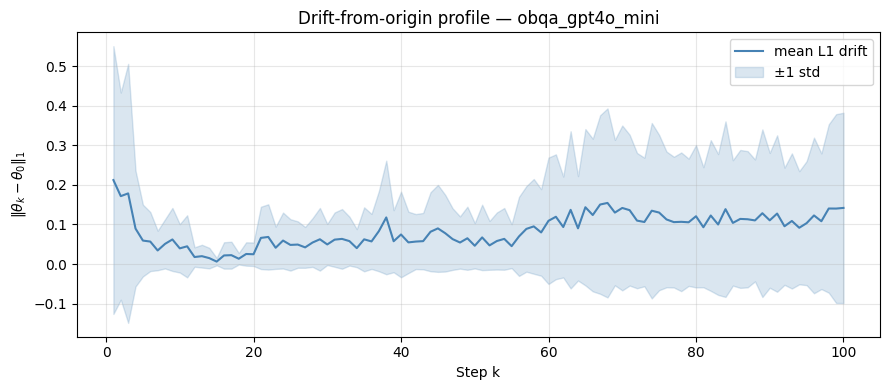

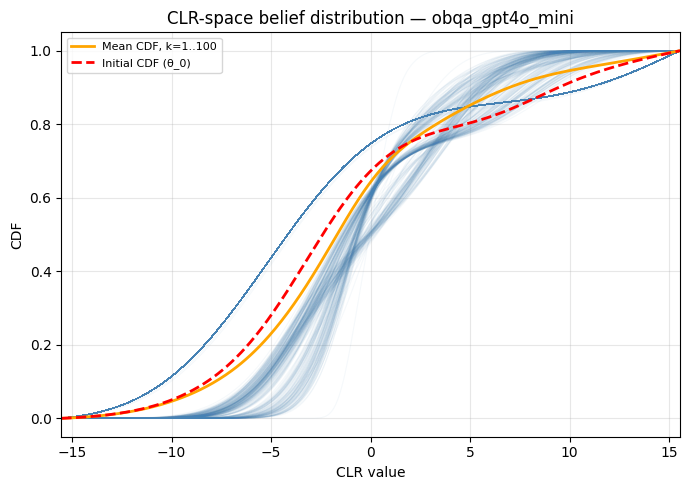

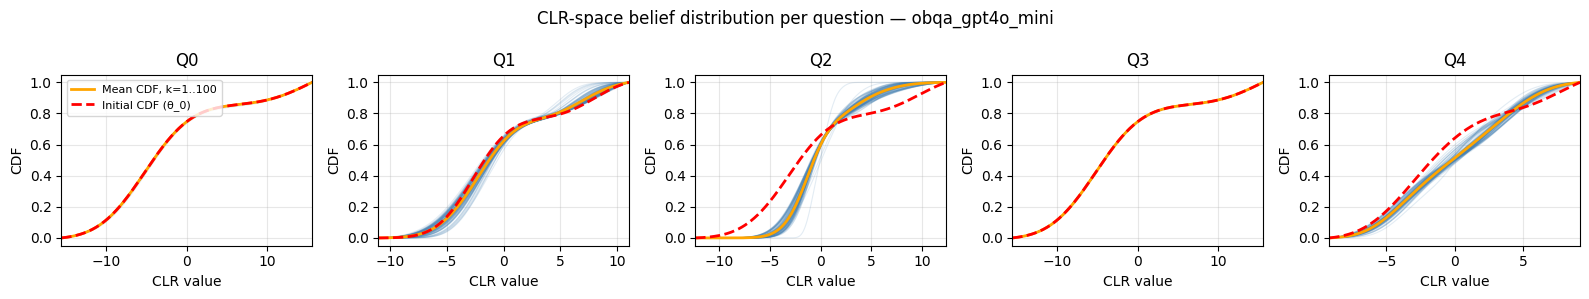

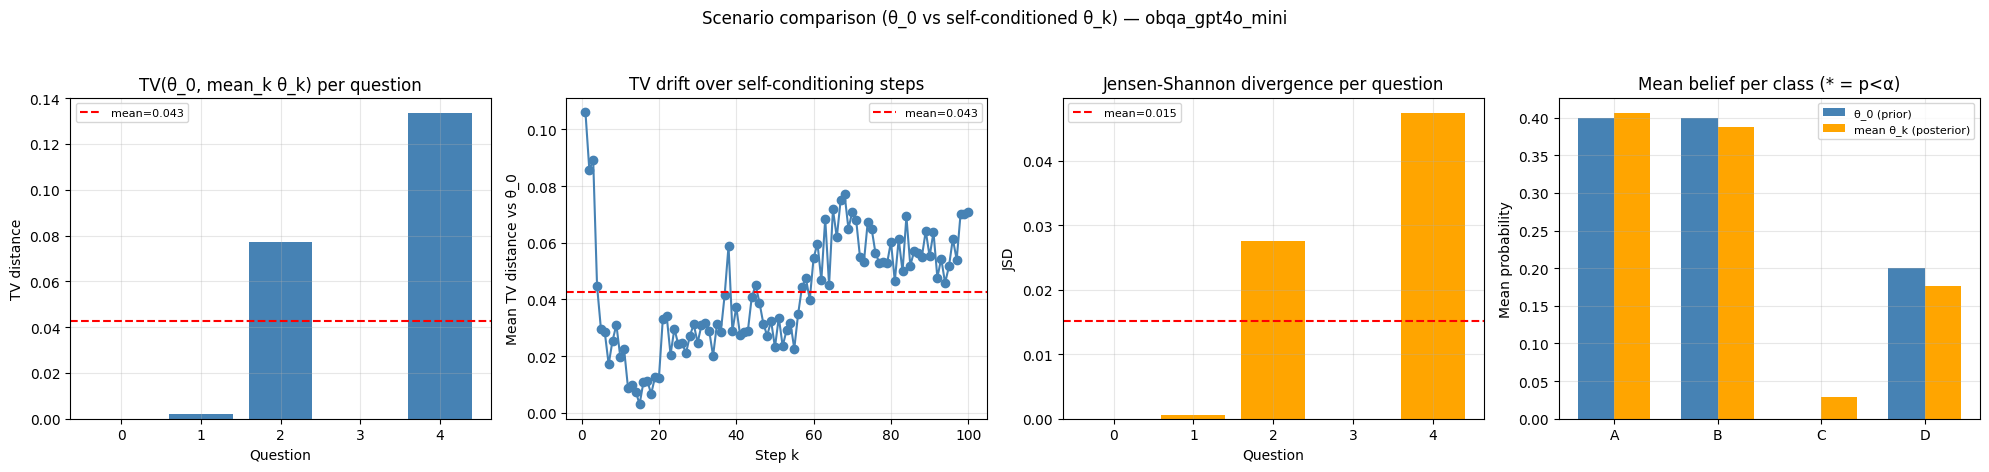

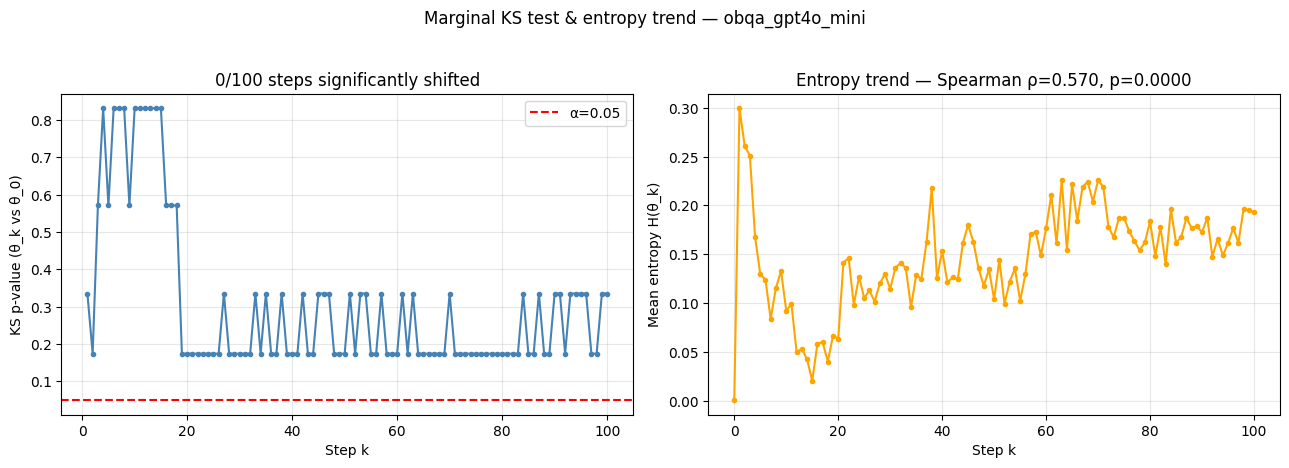

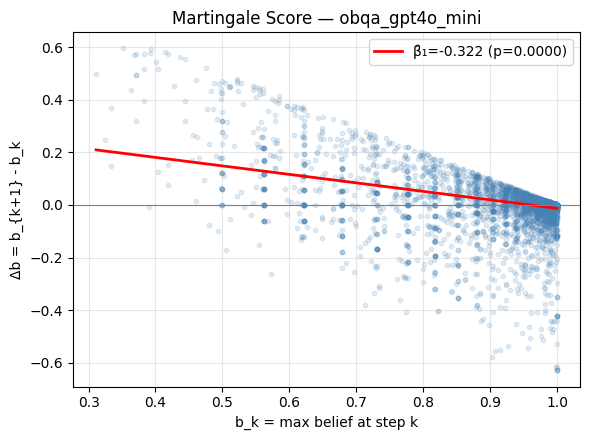

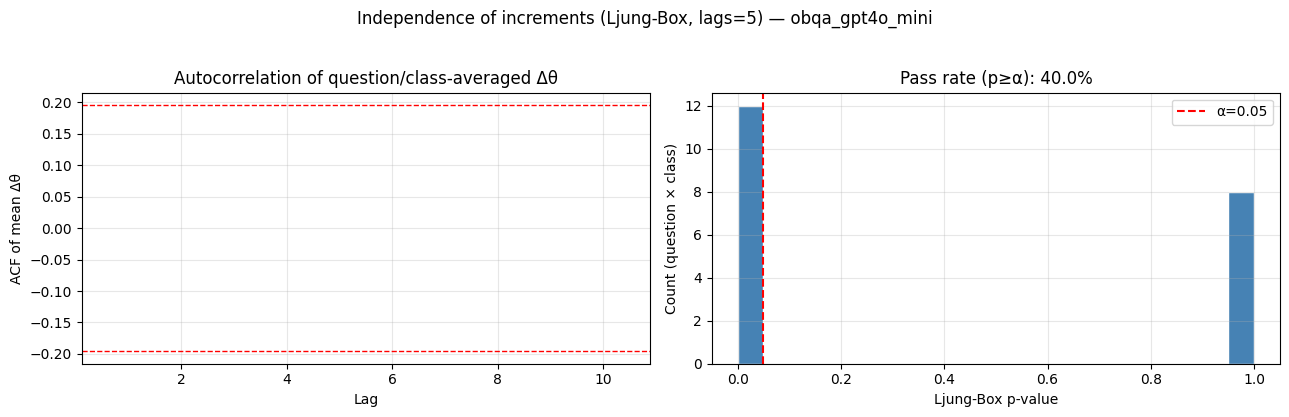

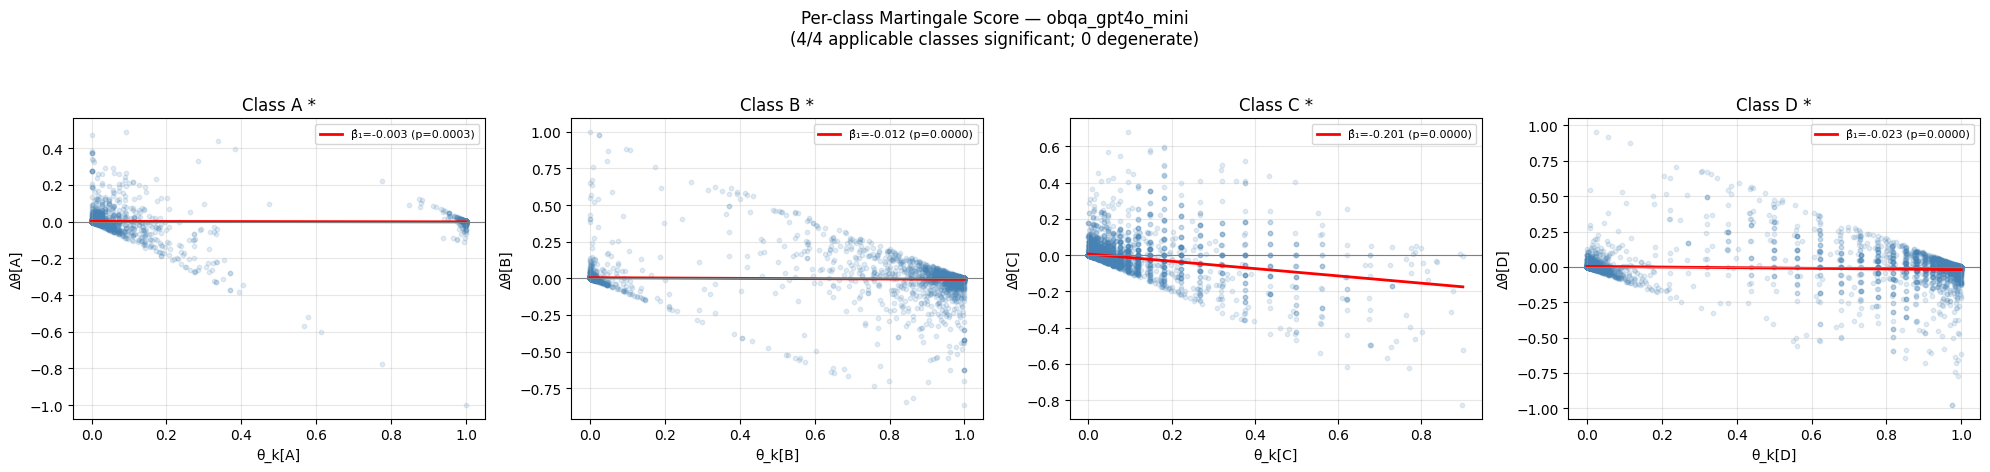

/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

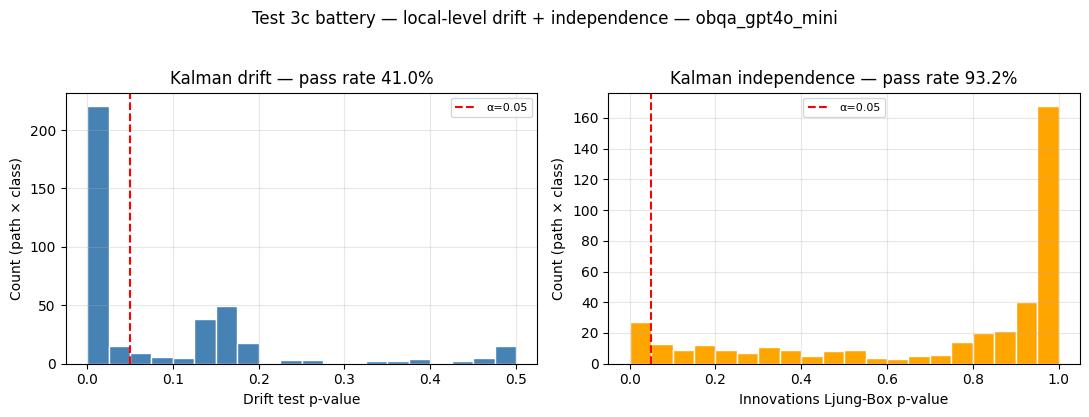

=== Verdict for obqa_gpt4o_mini ===
  Test 1 (scenario comparison)      : PASS  (TV=0.0426, KS p=0.0000, 0/4 classes shifted)
  Test 2 (marginal KS per step)     : PASS  (0/100 steps shifted, entropy ρ=0.570 p=0.0000)
  Test 3 (martingale score β̂₁)      : FAIL  (β̂₁=-0.3224, p=0.0000, R²=0.1571)
  Test 4 (Ljung-Box independence)   : FAIL  (pass rate=40.0% of 20 series)
  --> OVERALL (Tests 1/2/3/4): MARTINGALE VIOLATED

  --- Additional diagnostics (corrected for the differencing artifact) ---
  Test 3b (per-class score)         : 4/4 applicable classes significant (0 degenerate)
  Test 3c (Kalman drift)            : pass rate 41.0% of 400 series
  Test 3c (Kalman independence)     : pass rate 93.2% of 400 series


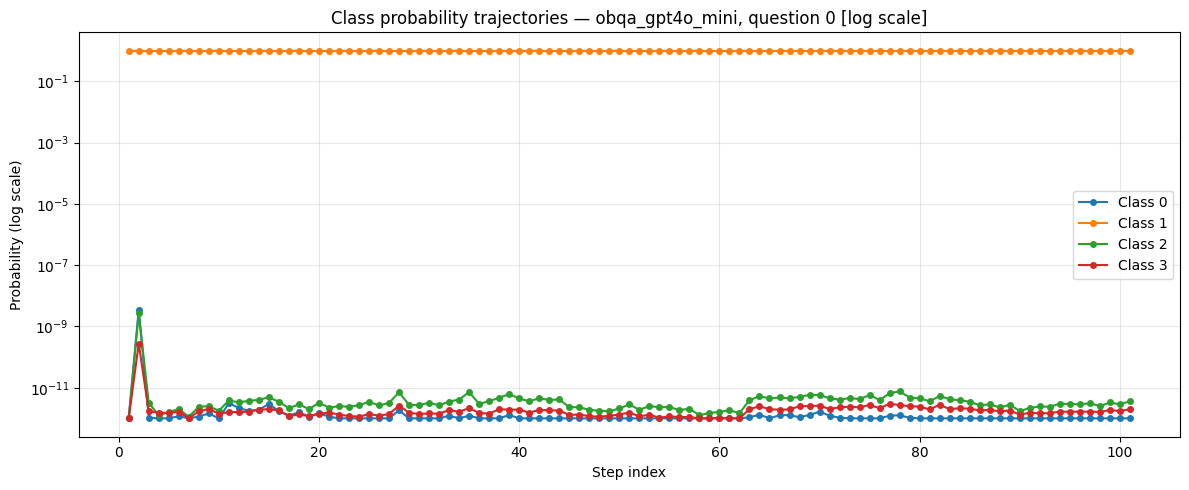

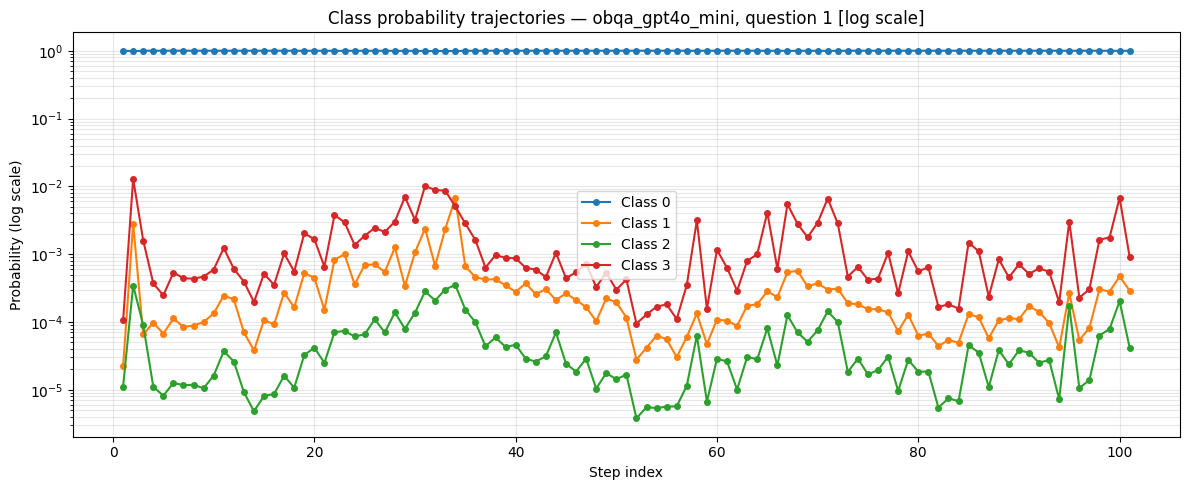

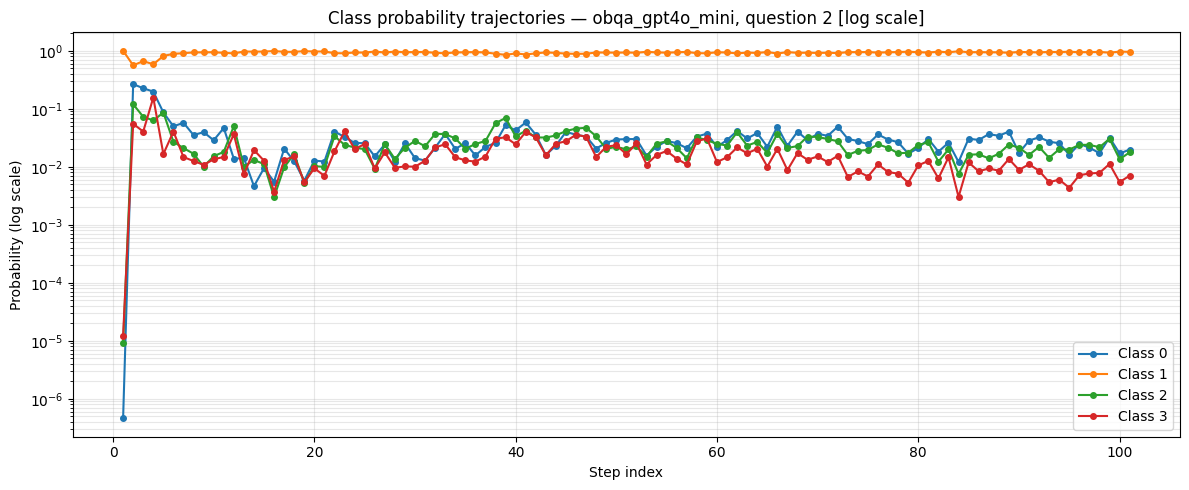

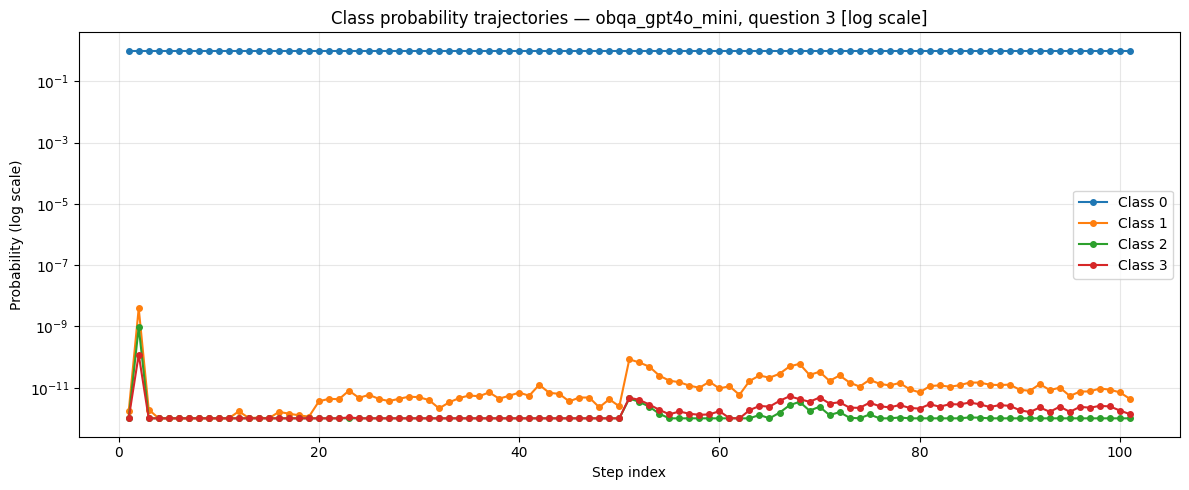

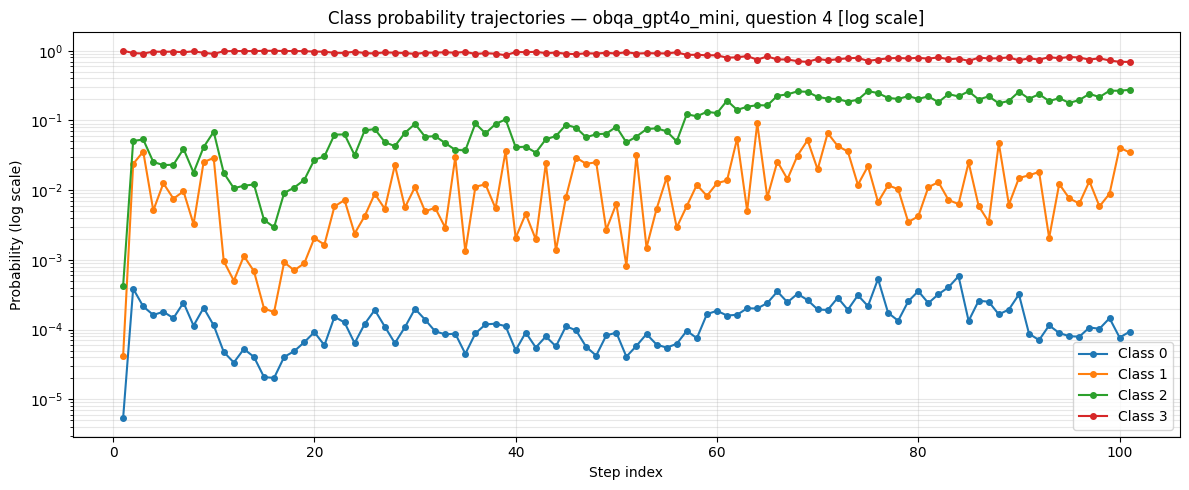

In [21]:
print("Available run keys:", registry["folder"].tolist())

DATASET_KEY = registry.loc[0, "folder"]  # <-- change this to inspect a different run
run_row = registry.loc[registry["folder"] == DATASET_KEY].iloc[0]
dat = load_run(run_row["npz_path"], seed=SEED)

print(f"\nDeep-diving into: {DATASET_KEY}  (dataset={run_row['dataset']}, model={run_row['model']})")
deep_dive_result = run_full_battery(dat, name=DATASET_KEY, alpha=0.05, make_plots=True)

# Distributions of probabilities of classes — every question, averaged over J
p_all_deep = dat["distributions"].mean(axis=1)  # (Q, K+1, C)
Q_deep, Kp1_deep, C_deep = p_all_deep.shape


def plot_class_trajectories(p_all_deep: np.ndarray, dataset_key: str, q: int,
                             log_scale: bool = False) -> None:
    """p_all_deep: (Q, K+1, C) -- J-averaged distributions. One line per class,
    x-axis = step index.

    log_scale=False (default): plain [0, 1] probability axis.
    log_scale=True: log-scale y-axis. Matters most when Q is small (e.g. a
    single question) -- probabilities near 0 or 1 are visually indistinguishable
    on a linear axis (0.999998 and 0.9999999874 both just look like "1"), the
    same compression problem the CLR-space CDF plot above is built to avoid.
    A log y-axis fixes this directly for a single class's own trajectory,
    without needing the full CLR machinery.
    """
    dat_q = p_all_deep[q]  # (K+1, C)
    Kp1, C = dat_q.shape
    x = np.arange(1, Kp1 + 1)

    fig, ax = plt.subplots(figsize=(12, 5))
    for c in range(C):
        y = dat_q[:, c]
        if log_scale:
            y = np.clip(y, 1e-12, 1.0)  # guard against exact 0 on a log axis
        ax.plot(x, y, marker='o', markersize=4, label=f"Class {c}")

    ax.set_xlabel("Step index")
    ax.set_ylabel("Probability" + (" (log scale)" if log_scale else ""))
    if log_scale:
        ax.set_yscale('log')
    ax.set_title(
        f"Class probability trajectories — {dataset_key}, question {q}"
        + (" [log scale]" if log_scale else "")
    )
    if Kp1 <= 40:
        ax.set_xticks(x)
    ax.legend()
    ax.grid(True, alpha=0.3, which='both' if log_scale else 'major')
    plt.tight_layout()
    plt.show()


LOG_SCALE = True  # <-- toggle: False = linear [0,1] axis, True = log y-axis

for q in range(Q_deep):
    plot_class_trajectories(p_all_deep, DATASET_KEY, q, log_scale=LOG_SCALE)


### Step-to-step probability changes (lagged differences)

Plots $\Delta\theta_k = \theta_k - \theta_{k-1}$ directly against step $k$,
one line per class -- the same `diff` series the per-class Martingale Score
regression above uses on its y-axis, but shown over time instead of against
the belief level $\theta_{k-1}$. A martingale-consistent process should show
these differences scattered around zero with no systematic trend as $k$
grows; a visible trend (e.g. differences shrinking toward zero, or drifting
away from it) is a direct, assumption-free look at the same drift the
regression is trying to summarize into a single slope.


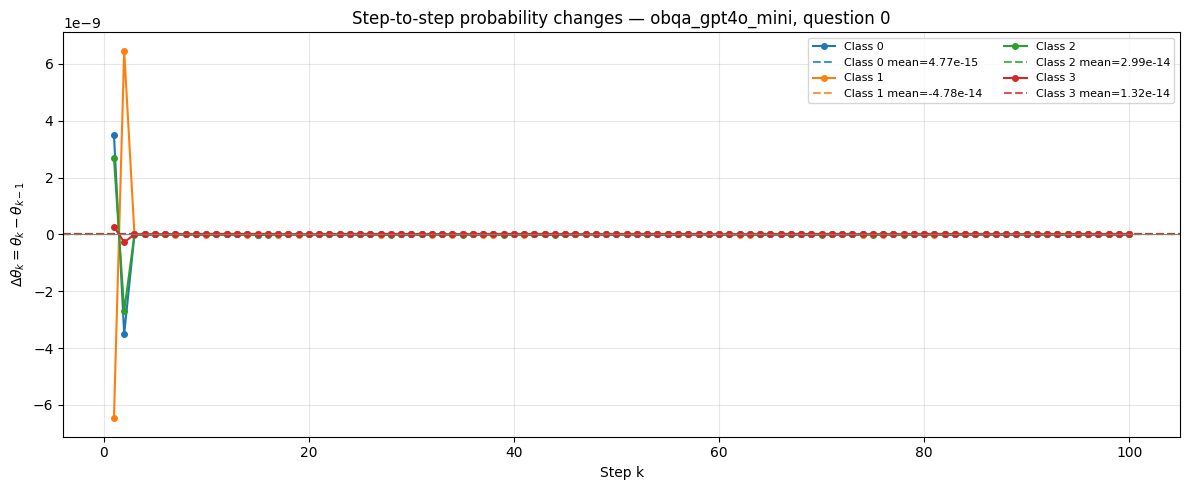

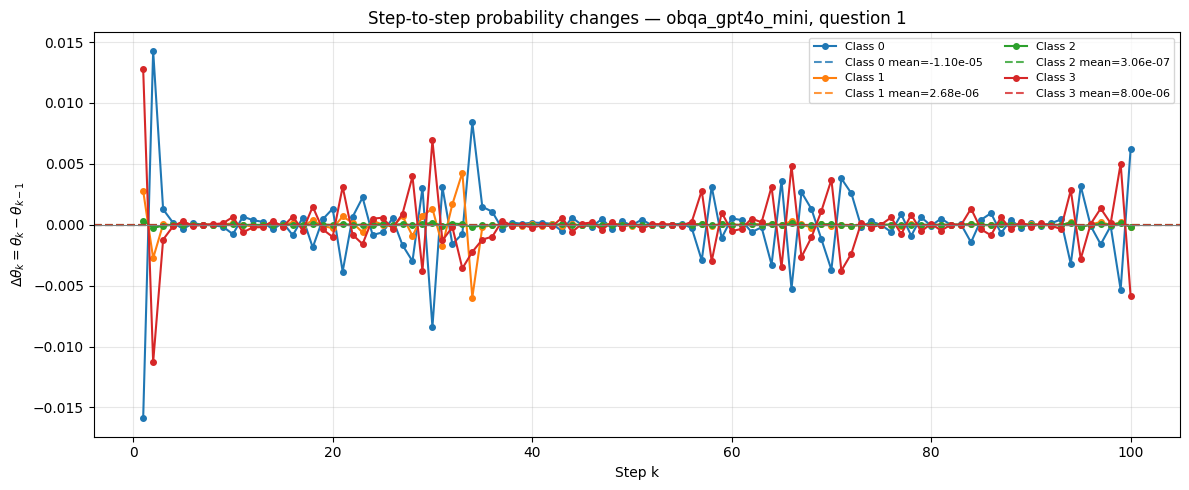

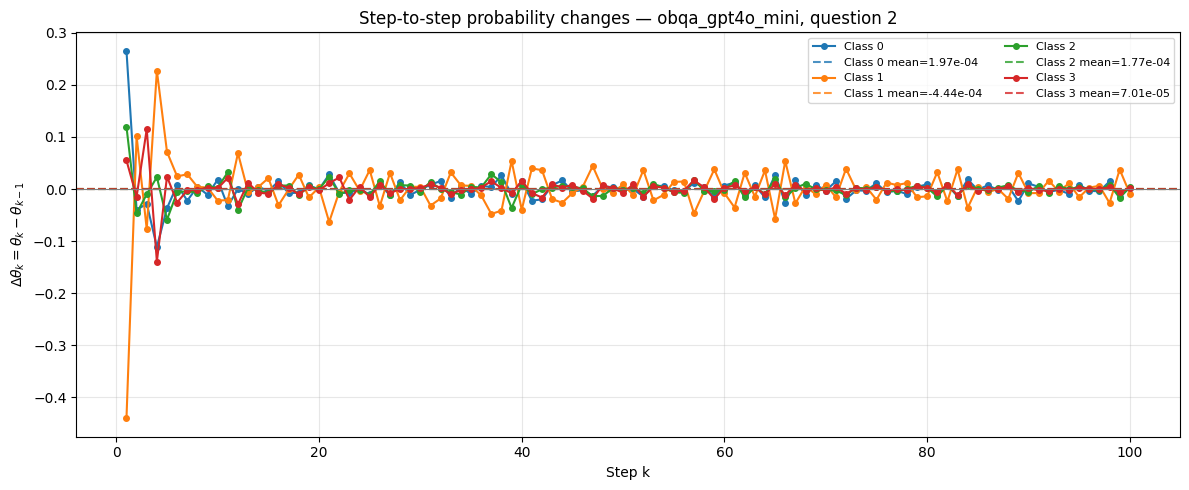

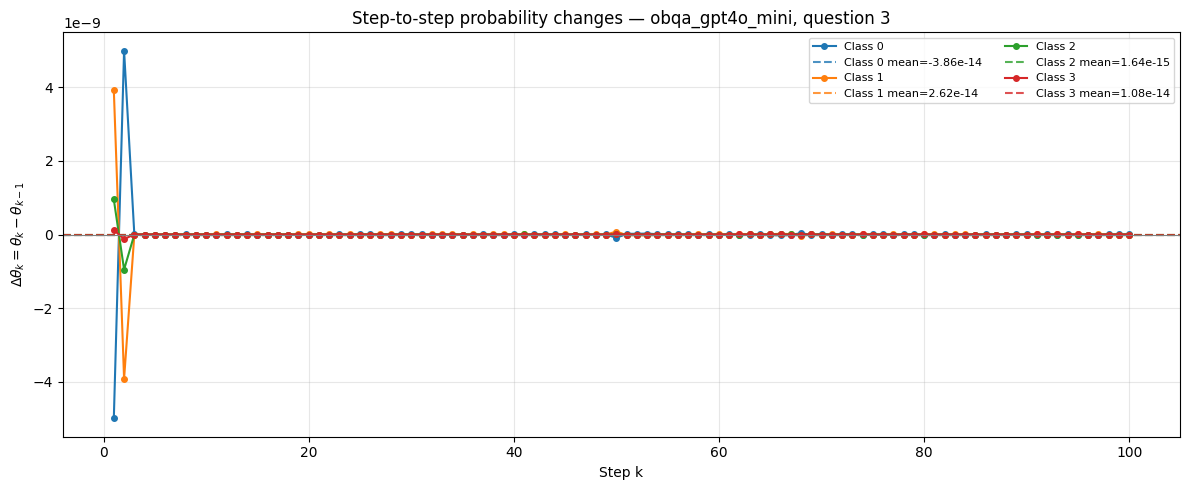

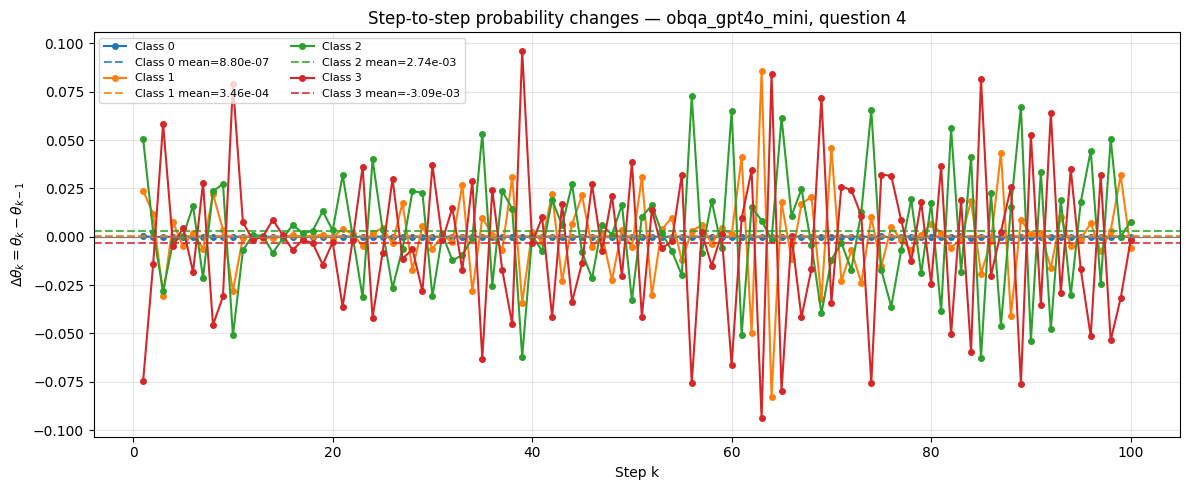

In [23]:
p_all_diff_deep = dat["distributions"].mean(axis=1)  # (Q, K+1, C), J-averaged
Q_diff, Kp1_diff, C_diff = p_all_diff_deep.shape

for q in range(Q_diff):
    theta_q = p_all_diff_deep[q]          # (K+1, C)
    diffs_q = np.diff(theta_q, axis=0)    # (K, C): diffs_q[k-1] = theta_k - theta_{k-1}
    k_axis = np.arange(1, Kp1_diff)       # step indices k = 1..K

    fig, ax = plt.subplots(figsize=(12, 5))
    for c in range(C_diff):
        line, = ax.plot(k_axis, diffs_q[:, c], marker='o', markersize=4, label=f"Class {c}")
        mean_c = diffs_q[:, c].mean()
        ax.axhline(mean_c, color=line.get_color(), linestyle="--", linewidth=1.5, alpha=0.8,
                   label=f"Class {c} mean={mean_c:.2e}")

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Step k")
    ax.set_ylabel(r"$\Delta\theta_k = \theta_k - \theta_{k-1}$")
    ax.set_title(f"Step-to-step probability changes — {DATASET_KEY}, question {q}")
    if Kp1_diff <= 40:
        ax.set_xticks(k_axis)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Difference from the first step ($\theta_k - \theta_0$)

Complements the lagged (step-to-step) differences above: instead of
$\Delta\theta_k = \theta_k - \theta_{k-1}$ (reset each step), this plots
$\theta_k - \theta_0$ for every step $k = 1, \dots, K$ -- how far each class
has drifted from its very first (direct-query) value, accumulated over the
whole trajectory rather than measured one step at a time. A class whose
lagged differences hover around zero but whose cumulative difference here
keeps growing in one direction indicates a slow, consistent drift that's
easy to miss step-by-step but adds up over many steps.


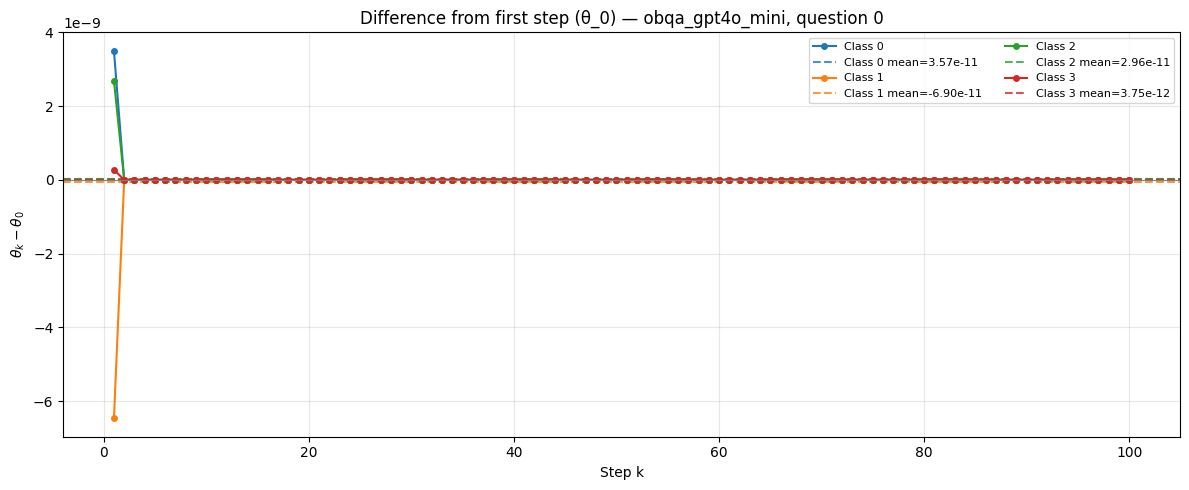

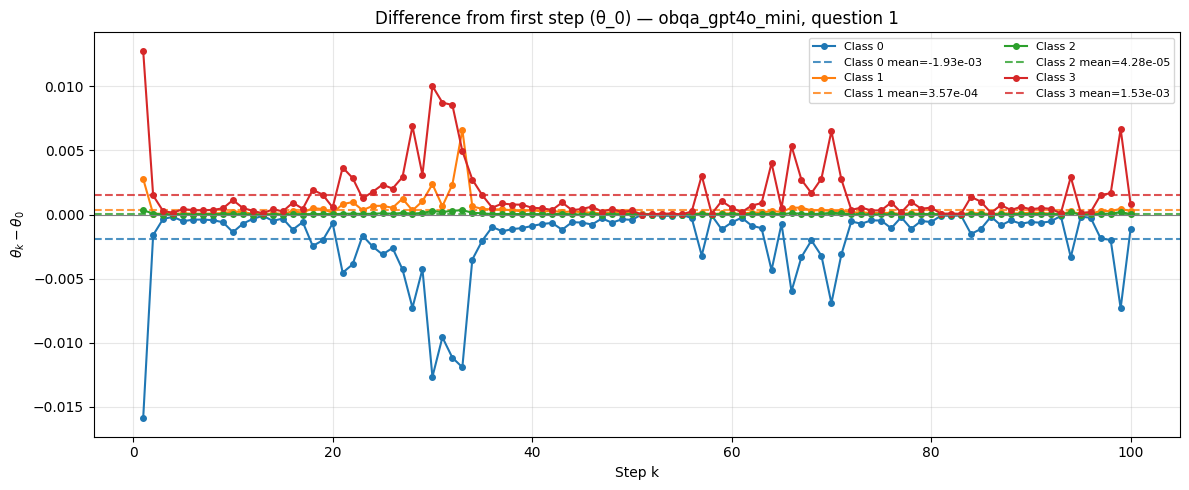

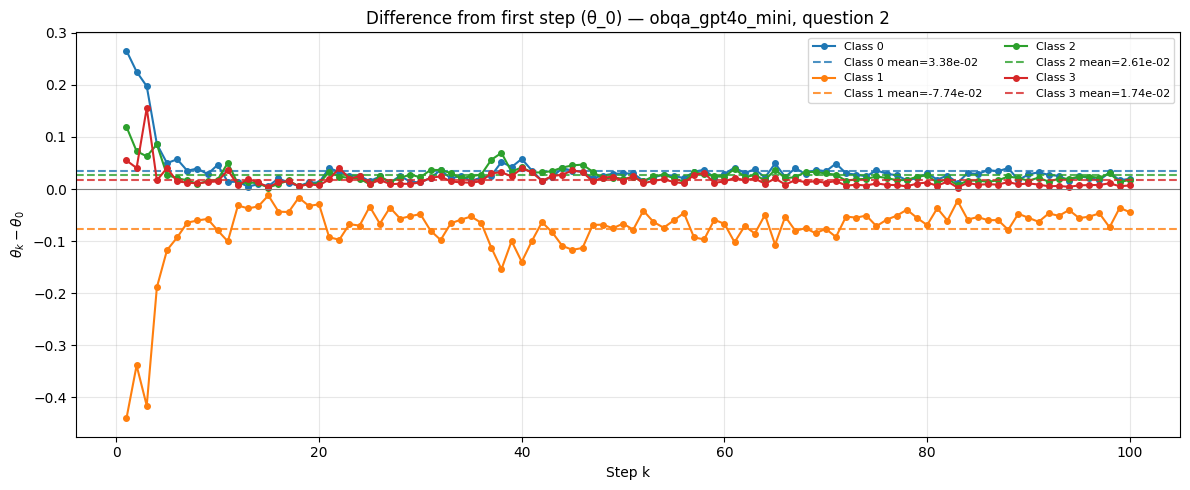

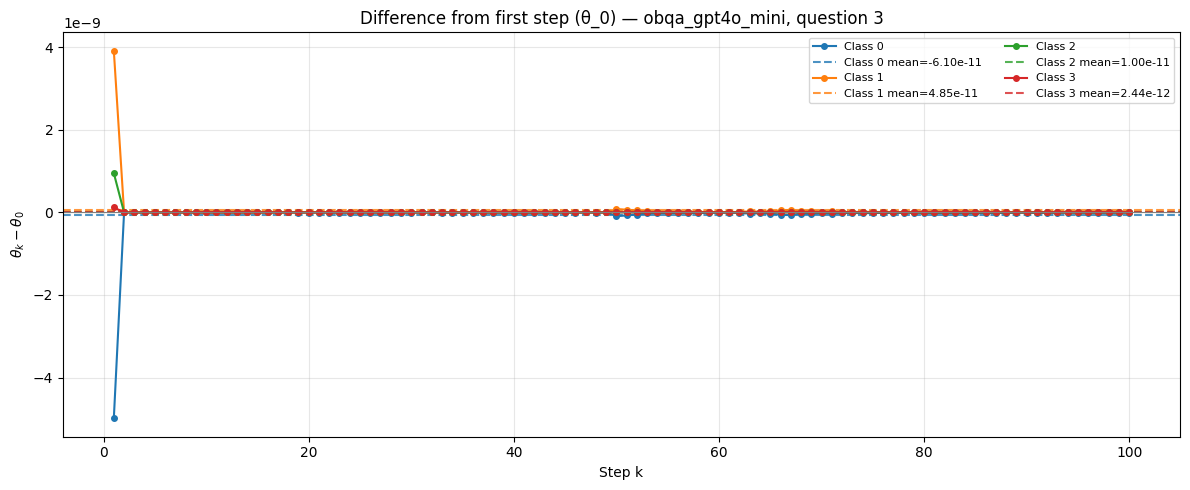

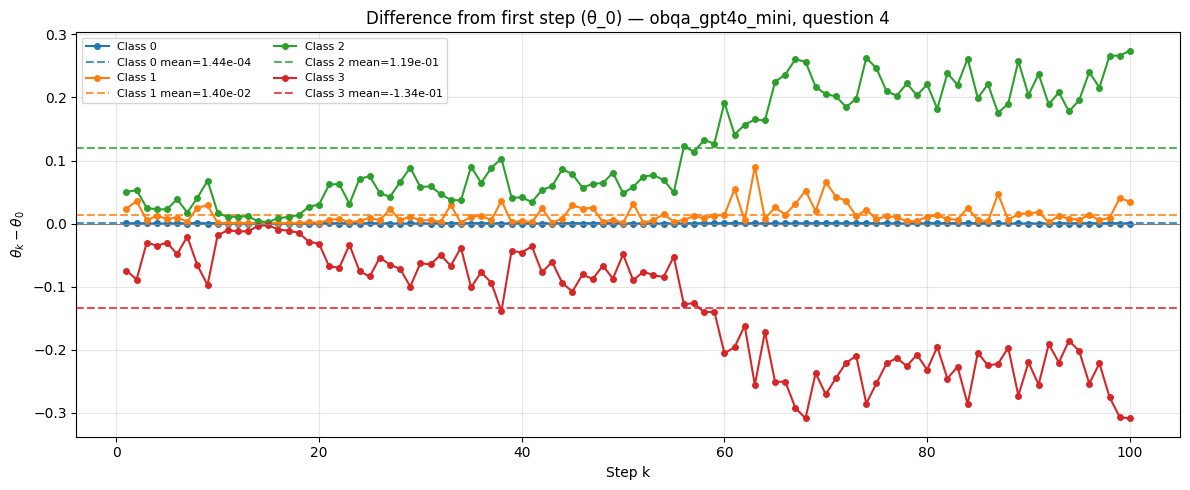

In [24]:
p_all_cum_deep = dat["distributions"].mean(axis=1)  # (Q, K+1, C), J-averaged
Q_cum, Kp1_cum, C_cum = p_all_cum_deep.shape

for q in range(Q_cum):
    theta_q = p_all_cum_deep[q]                        # (K+1, C)
    theta_first = theta_q[0]                            # theta_0 -- the first step
    cum_diff_q = theta_q[1:] - theta_first[None, :]      # (K, C): theta_k - theta_0, k=1..K
    k_axis = np.arange(1, Kp1_cum)

    fig, ax = plt.subplots(figsize=(12, 5))
    for c in range(C_cum):
        line, = ax.plot(k_axis, cum_diff_q[:, c], marker='o', markersize=4, label=f"Class {c}")
        mean_c = cum_diff_q[:, c].mean()
        ax.axhline(mean_c, color=line.get_color(), linestyle="--", linewidth=1.5, alpha=0.8,
                   label=f"Class {c} mean={mean_c:.2e}")

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Step k")
    ax.set_ylabel(r"$\theta_k - \theta_0$")
    ax.set_title(f"Difference from first step (θ_0) — {DATASET_KEY}, question {q}")
    if Kp1_cum <= 40:
        ax.set_xticks(k_axis)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. Batch verdicts across every available run

Runs the same battery (statistics only, no plots) over every completed run
and collects the four test verdicts plus an overall call into one table.


In [26]:
ALPHA = 0.05
batch_results = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    res = run_full_battery(dat, name=row["folder"], alpha=ALPHA, make_plots=False)
    batch_results.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "scenario_tv": res["scenario"]["tv_mean"],
        "scenario_pass": res["scenario"]["martingale_consistent"],
        "marginal_sig_steps": f"{res['marginal']['n_sig_steps']}/{res['marginal']['n_steps']}",
        "marginal_pass": res["marginal"]["martingale_consistent"],
        "score_beta1": res["score"]["beta_1"],
        "score_pval": res["score"]["p_value"],
        "score_pass": res["score"]["martingale_consistent"] if not res["score"]["degenerate"] else "N/A (one-hot)",
        "indep_pass_rate": res["independence"]["pass_rate"],
        "indep_pass": res["independence"]["martingale_consistent"],
        "OVERALL": "CONSISTENT" if res["overall_consistent"] else "VIOLATED",
        # Additional diagnostics (Test 3b, Test 3c) -- corrected for the
        # differencing artifact; not part of OVERALL, reported alongside it.
        "score3b_sig": f"{res['score_per_class']['n_sig_classes']}/{res['score_per_class']['n_applicable']}",
        "kalman_drift_pass_rate": res["kalman"]["drift_pass_rate"],
        "kalman_indep_pass_rate": res["kalman"]["indep_pass_rate"],
        "kalman_pass": res["kalman"]["martingale_consistent"],
    })

summary = pd.DataFrame(batch_results)
summary


/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/alicansahin/opt/anaconda3/envs/llm-duos/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

,dataset,model,scenario_tv,scenario_pass,marginal_sig_steps,marginal_pass,score_beta1,score_pval,score_pass,indep_pass_rate,indep_pass,OVERALL,score3b_sig,kalman_drift_pass_rate,kalman_indep_pass_rate,kalman_pass
0,obqa,gpt4o_mini,0.034111,True,1/100,False,-0.28224,3.650041e-34,False,0.425,False,VIOLATED,2/4,0.575,0.925,False


In [27]:
def _highlight_overall(row):
    color = "background-color: #c8e6c9" if row["OVERALL"] == "CONSISTENT" else "background-color: #ffcdd2"
    return [color if col == "OVERALL" else "" for col in row.index]

summary.style.apply(_highlight_overall, axis=1).format({
    "scenario_tv": "{:.4f}", "score_beta1": "{:.4f}", "score_pval": "{:.4f}",
    "indep_pass_rate": "{:.1%}",
    "kalman_drift_pass_rate": "{:.1%}", "kalman_indep_pass_rate": "{:.1%}",
})


,dataset,model,scenario_tv,scenario_pass,marginal_sig_steps,marginal_pass,score_beta1,score_pval,score_pass,indep_pass_rate,indep_pass,OVERALL,score3b_sig,kalman_drift_pass_rate,kalman_indep_pass_rate,kalman_pass
0,obqa,gpt4o_mini,0.0341,True,1/100,False,-0.2822,0.0000,False,42.5%,False,VIOLATED,2/4,57.5%,92.5%,False
